findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following

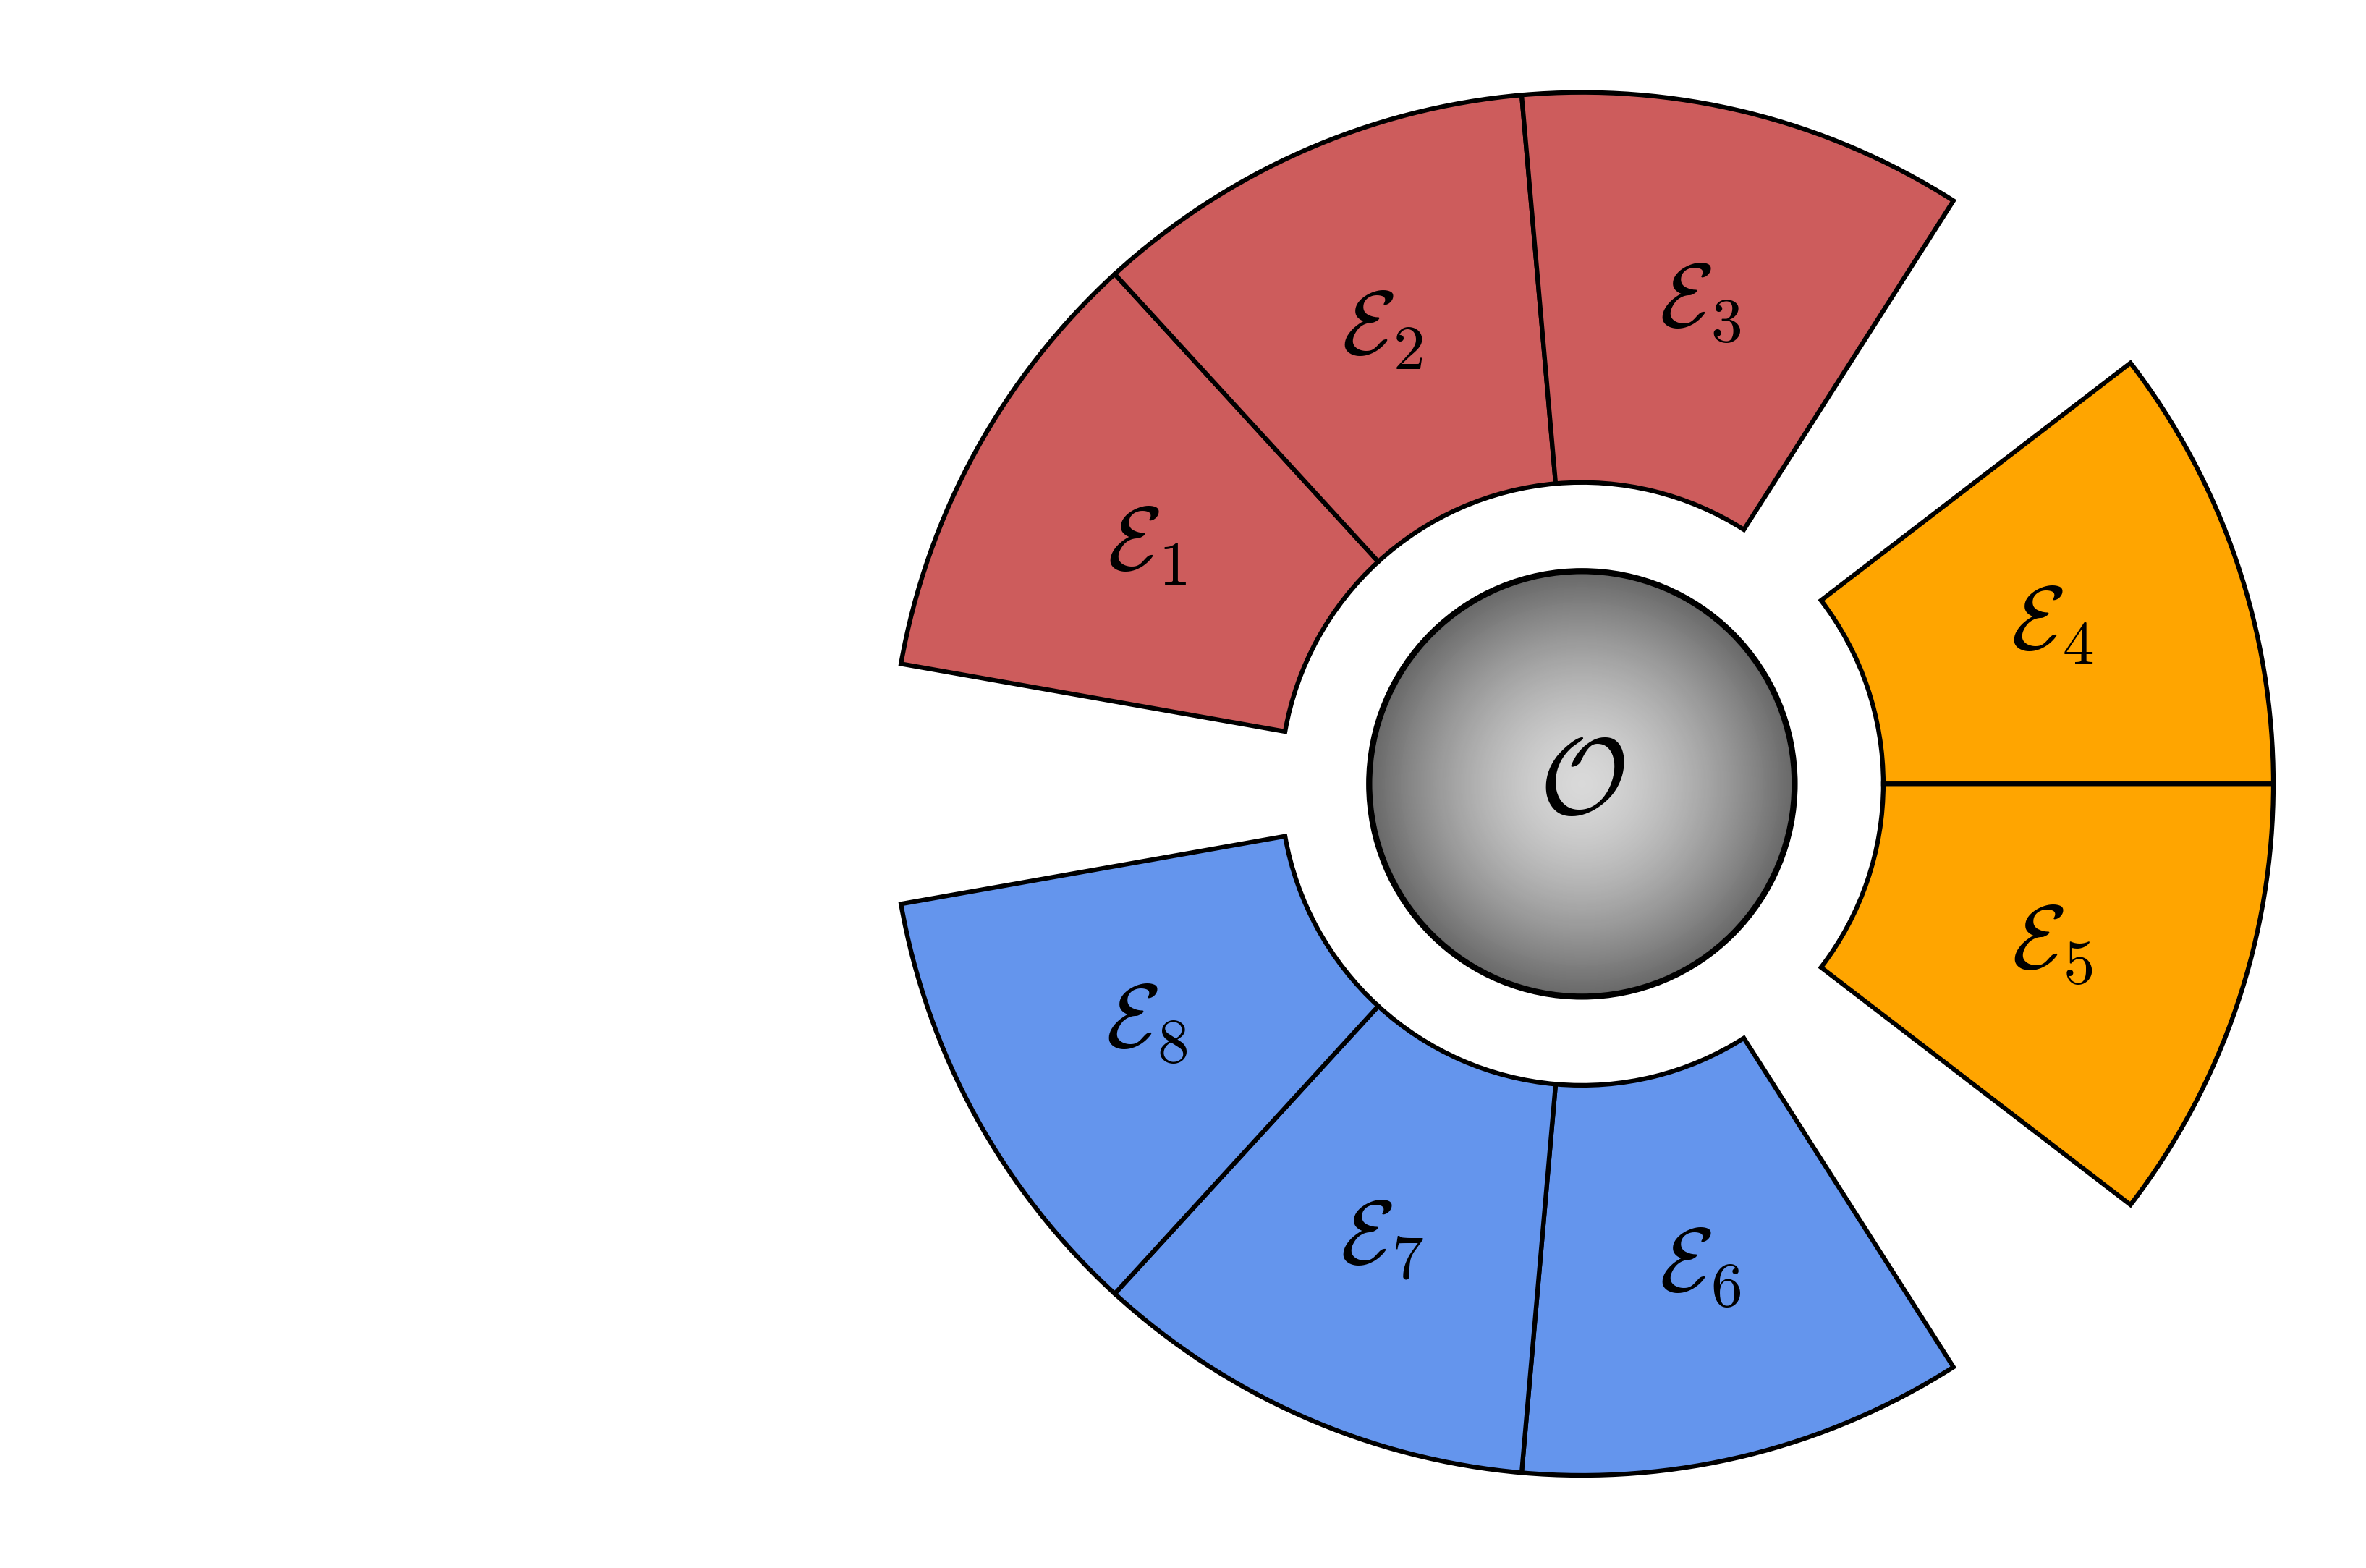

In [80]:
# QD - Zurek Picture Illustration 
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Wedge, Circle

# Cấu hình phông chữ LaTeX (Computer Modern)
plt.rcParams.update({
    'font.family': 'serif',
    'mathtext.fontset': 'cm',
    'figure.facecolor': 'white'
})

fig, ax = plt.subplots(figsize=(11, 8), dpi=300)

# ==========================================
# THIẾT LẬP KÍCH THƯỚC VÀ KHOẢNG CÁCH
# ==========================================
r_object = 0.60                      # Bán kính đối tượng O trung tâm
radial_gap = 0.25                    # Khoảng cách từ O đến môi trường E
r_inner_env = r_object + radial_gap  # Bán kính trong môi trường E
r_outer_env = 1.95                   # Bán kính ngoài môi trường E

# Cấu hình 3 CỤM MÔI TRƯỜNG E (Tổng = 8 mảnh)
clusters = [3, 2, 3]                 # Cụm 1 (Đỏ): 3 mảnh, Cụm 2 (Vàng): 2 mảnh, Cụm 3 (Xanh): 3 mảnh
cluster_gap_deg = 20                 # Góc hở (độ) giữa các cụm

# Màu sắc theo thứ tự từ trái sang phải
cluster_colors = ['indianred', 'orange', 'cornflowerblue']

total_gaps_deg = len(clusters) * cluster_gap_deg
total_fragments = sum(clusters)
slice_angle = (360 - total_gaps_deg) / total_fragments  # ~32.5 độ/mảnh

# Tọa độ vị trí cho hình tròn S (đặt bên trái, x_S < 0)
x_S, y_S = -3.5, 0.0                 # Tâm hình tròn S bên trái
r_S = 0.60                           # Bán kính hình tròn S

# ==========================================
# 1. VẼ 3 CỤM MÔI TRƯỜNG VỚI MÀU SẮC & THỨ TỰ TỪ TRÁI SANG PHẢI
# ==========================================
# Bắt đầu vẽ từ cụm đỏ ở phía trên bên trái (sau khe hở phía trái 180 độ)
# Đi theo chiều kim đồng hồ để xếp thứ tự mảnh từ trái sang phải (từ góc ~170° giảm dần về góc tiêu chuẩn)
start_angle = 180 - cluster_gap_deg / 2
current_angle = start_angle

fragment_counter = 1

for cluster_idx, num_frags in enumerate(clusters):
    current_color = cluster_colors[cluster_idx]
    
    for i in range(num_frags):
        theta1 = current_angle - slice_angle
        theta2 = current_angle
        
        # Vẽ miếng vành khăn với màu theo cụm
        wedge = Wedge(
            center=(0, 0), r=r_outer_env, theta1=theta1, theta2=theta2, 
            width=r_outer_env - r_inner_env,
            facecolor=current_color, edgecolor='black', linewidth=1.5, zorder=1
        )
        ax.add_patch(wedge)
        
        # Tính vị trí và ghi nhãn \mathcal{E}_i
        angle_mid = np.radians((theta1 + theta2) / 2)
        r_label = (r_inner_env + r_outer_env) / 2
        x_lbl = r_label * np.cos(angle_mid)
        y_lbl = r_label * np.sin(angle_mid)
        
        ax.text(
            x_lbl, y_lbl, rf'$\mathcal{{E}}_{{{fragment_counter}}}$', 
            fontsize=30, fontweight='bold', color='black',
            ha='center', va='center', zorder=4
        )
        
        current_angle -= slice_angle
        fragment_counter += 1
        
    # Tạo khe hở góc sau mỗi cụm
    current_angle -= cluster_gap_deg

# ==========================================
# 2. VẼ ĐƯỜNG NẰM NGANG NỐI S VÀ O
# ==========================================


# ==========================================
# 3. VẼ HÌNH TRÒN O VÀ S (GRADIENT XÁM 3D)
# ==========================================
def draw_gradient_circle(center_x, center_y, radius, z_base):
    N = 150
    for r in np.linspace(0, radius, N)[::-1]:
        gray_val = 0.85 - 0.45 * (r / radius)**1.5
        circle = Circle((center_x, center_y), r, color=(gray_val, gray_val, gray_val), zorder=z_base)
        ax.add_patch(circle)
    border = Circle((center_x, center_y), radius, fill=False, edgecolor='black', linewidth=2.0, zorder=z_base+1)
    ax.add_patch(border)

# Vẽ O tại gốc tọa độ (0,0)
draw_gradient_circle(0, 0, r_object, z_base=2)
ax.text(0, 0, r'$\mathcal{O}$', fontsize=36, fontstyle='italic', ha='center', va='center', zorder=5)


# ==========================================
# 4. CẤU HÌNH CỬA SỔ HÌNH VẼ
# ==========================================
ax.set_xlim(x_S - r_S - 0.3, r_outer_env + 0.2)
ax.set_ylim(-r_outer_env - 0.2, r_outer_env + 0.2)
ax.set_aspect('equal')
ax.axis('off')

plt.tight_layout()
plt.savefig(r"Figure\QD_Zurek_Illustration.eps", dpi=600, bbox_inches='tight')
plt.savefig(r"Figure\QD_Zurek_Illustration.png", dpi=600, bbox_inches='tight')
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


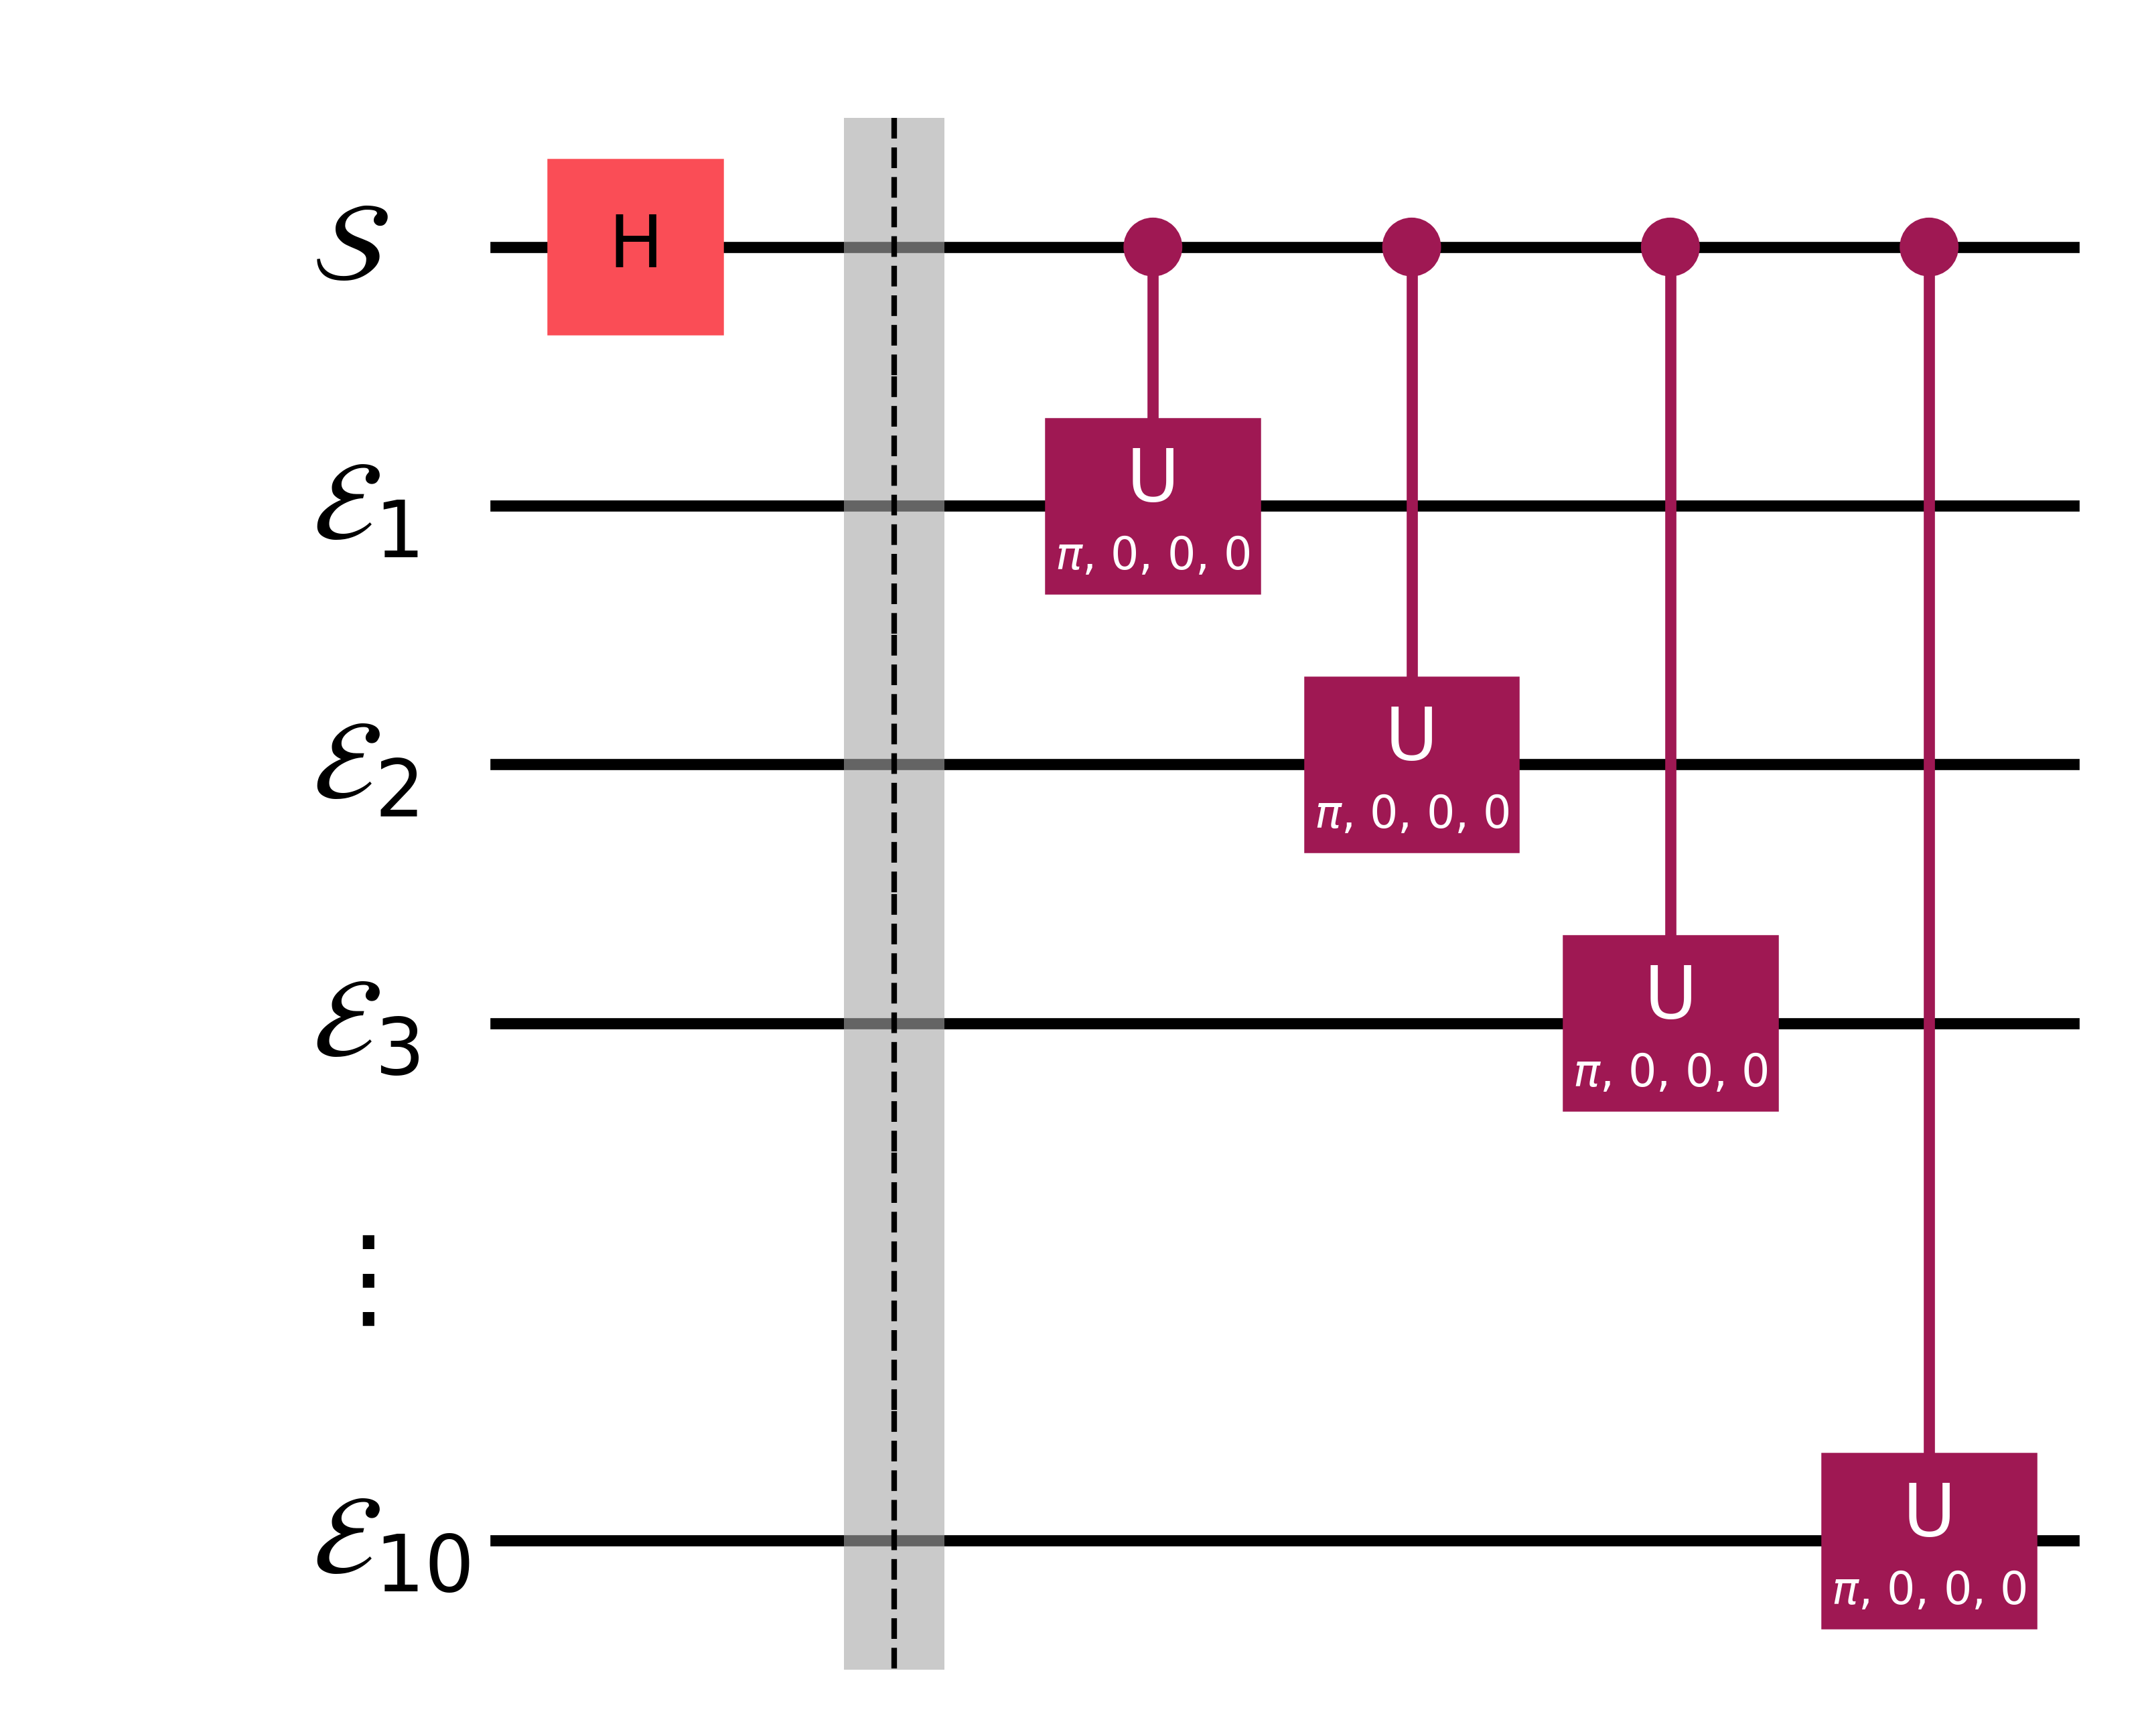

In [1]:
# QC-Zurek 
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, QuantumRegister
from qiskit.circuit import Parameter
from qiskit.circuit.library import UGate

# Thiết lập độ phân giải cao cho hình ảnh
mpl.rcParams['figure.dpi'] = 600

# Khai báo các thanh ghi (giữ tên phân biệt để tránh lỗi trùng tên)
q0 = QuantumRegister(1, 'q0')
q1 = QuantumRegister(1, 'q1')
q2 = QuantumRegister(1, 'q2')
q3 = QuantumRegister(1, 'q3')
qdots = QuantumRegister(1, 'qdots')
q11 = QuantumRegister(1, 'q11')

# Khởi tạo mạch
qc = QuantumCircuit(q0, q1, q2, q3, qdots, q11)

# Khối khởi tạo
qc.h(q0)
qc.barrier()

# Khối tương tác môi trường
u3_gate = UGate(np.pi, 0, 0, label="U").control(1)
qc.append(u3_gate, [q0, q1])
qc.append(u3_gate, [q0, q2])
qc.append(u3_gate, [q0, q3])
qc.append(u3_gate, [q0, q11])

# 1. Vẽ mạch từ Qiskit bằng MPL backend
fig = qc.draw(output="mpl", idle_wires=True)
ax = fig.axes[0]

# 2. Xử lý các nhãn gốc: ẩn văn bản và xóa hộp bbox
original_y_coords = []
for text in ax.texts:
    x, y = text.get_position()
    # Các nhãn qubit luôn nằm bên trái dây (x < 0)
    if x < 0:
        original_y_coords.append(y)
        # Ẩn văn bản cũ
        text.set_visible(False)
        # !!! SỬA LỖI TẠI ĐÂY !!!
        # Xóa bỏ hộp bbox mặc định để nó không đè lên chữ mới
        text.set_bbox(dict(facecolor='none', edgecolor='none', alpha=0.0))

# Sắp xếp tọa độ y thực tế từ trên xuống dưới
original_y_coords = sorted(original_y_coords, reverse=True)

# 3. Danh sách nhãn LaTeX theo đúng thứ tự: S -> E1 -> E2 -> E3 -> ⋮ -> E11
latex_labels = [
    r'$\mathcal{S}$',
    r'$\mathcal{E}_1$',
    r'$\mathcal{E}_2$',
    r'$\mathcal{E}_3$',
    r'$\vdots$',
    r'$\mathcal{E}_{10}$'
]

# 4. Ghi đè nhãn LaTeX mới vào đúng tọa độ y của từng dây
# Tinh chỉnh độ cao bằng y_offset nếu cần (ví dụ -0.05)
y_offset = -0.01
y_dots = original_y_coords[4]
x_offset = -0.95  # Dịch sang trái để tránh trùng với dây
for line in ax.lines:
    ydata = line.get_ydata()
    if len(ydata) > 0 and all(np.isclose(y, y_dots) for y in ydata):
        line.set_visible(False)  # Ẩn hoàn toàn wire
for y_pos, label in zip(original_y_coords, latex_labels):
    # Dấu 3 chấm đứng nhích nhẹ sang phải cho thẳng hàng với chữ E
    x_pos = x_offset if label == r'$\vdots$' else x_offset
    
    ax.text(
        x_pos, y_pos + y_offset, label,
        fontsize=20,
        ha='left', # Căn lề phải
        va='center', # Căn giữa theo chiều dọc
        color='black',
        zorder=100  # Đảm bảo chữ luôn nằm trên cùng
    )
fig.savefig(r"Figure\QC_Zurek.eps", dpi=600, bbox_inches='tight')
fig.savefig(r"Figure\QC_Zurek.png", dpi=600, bbox_inches='tight')
# Hiển thị hình
fig

findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Font family ['serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman


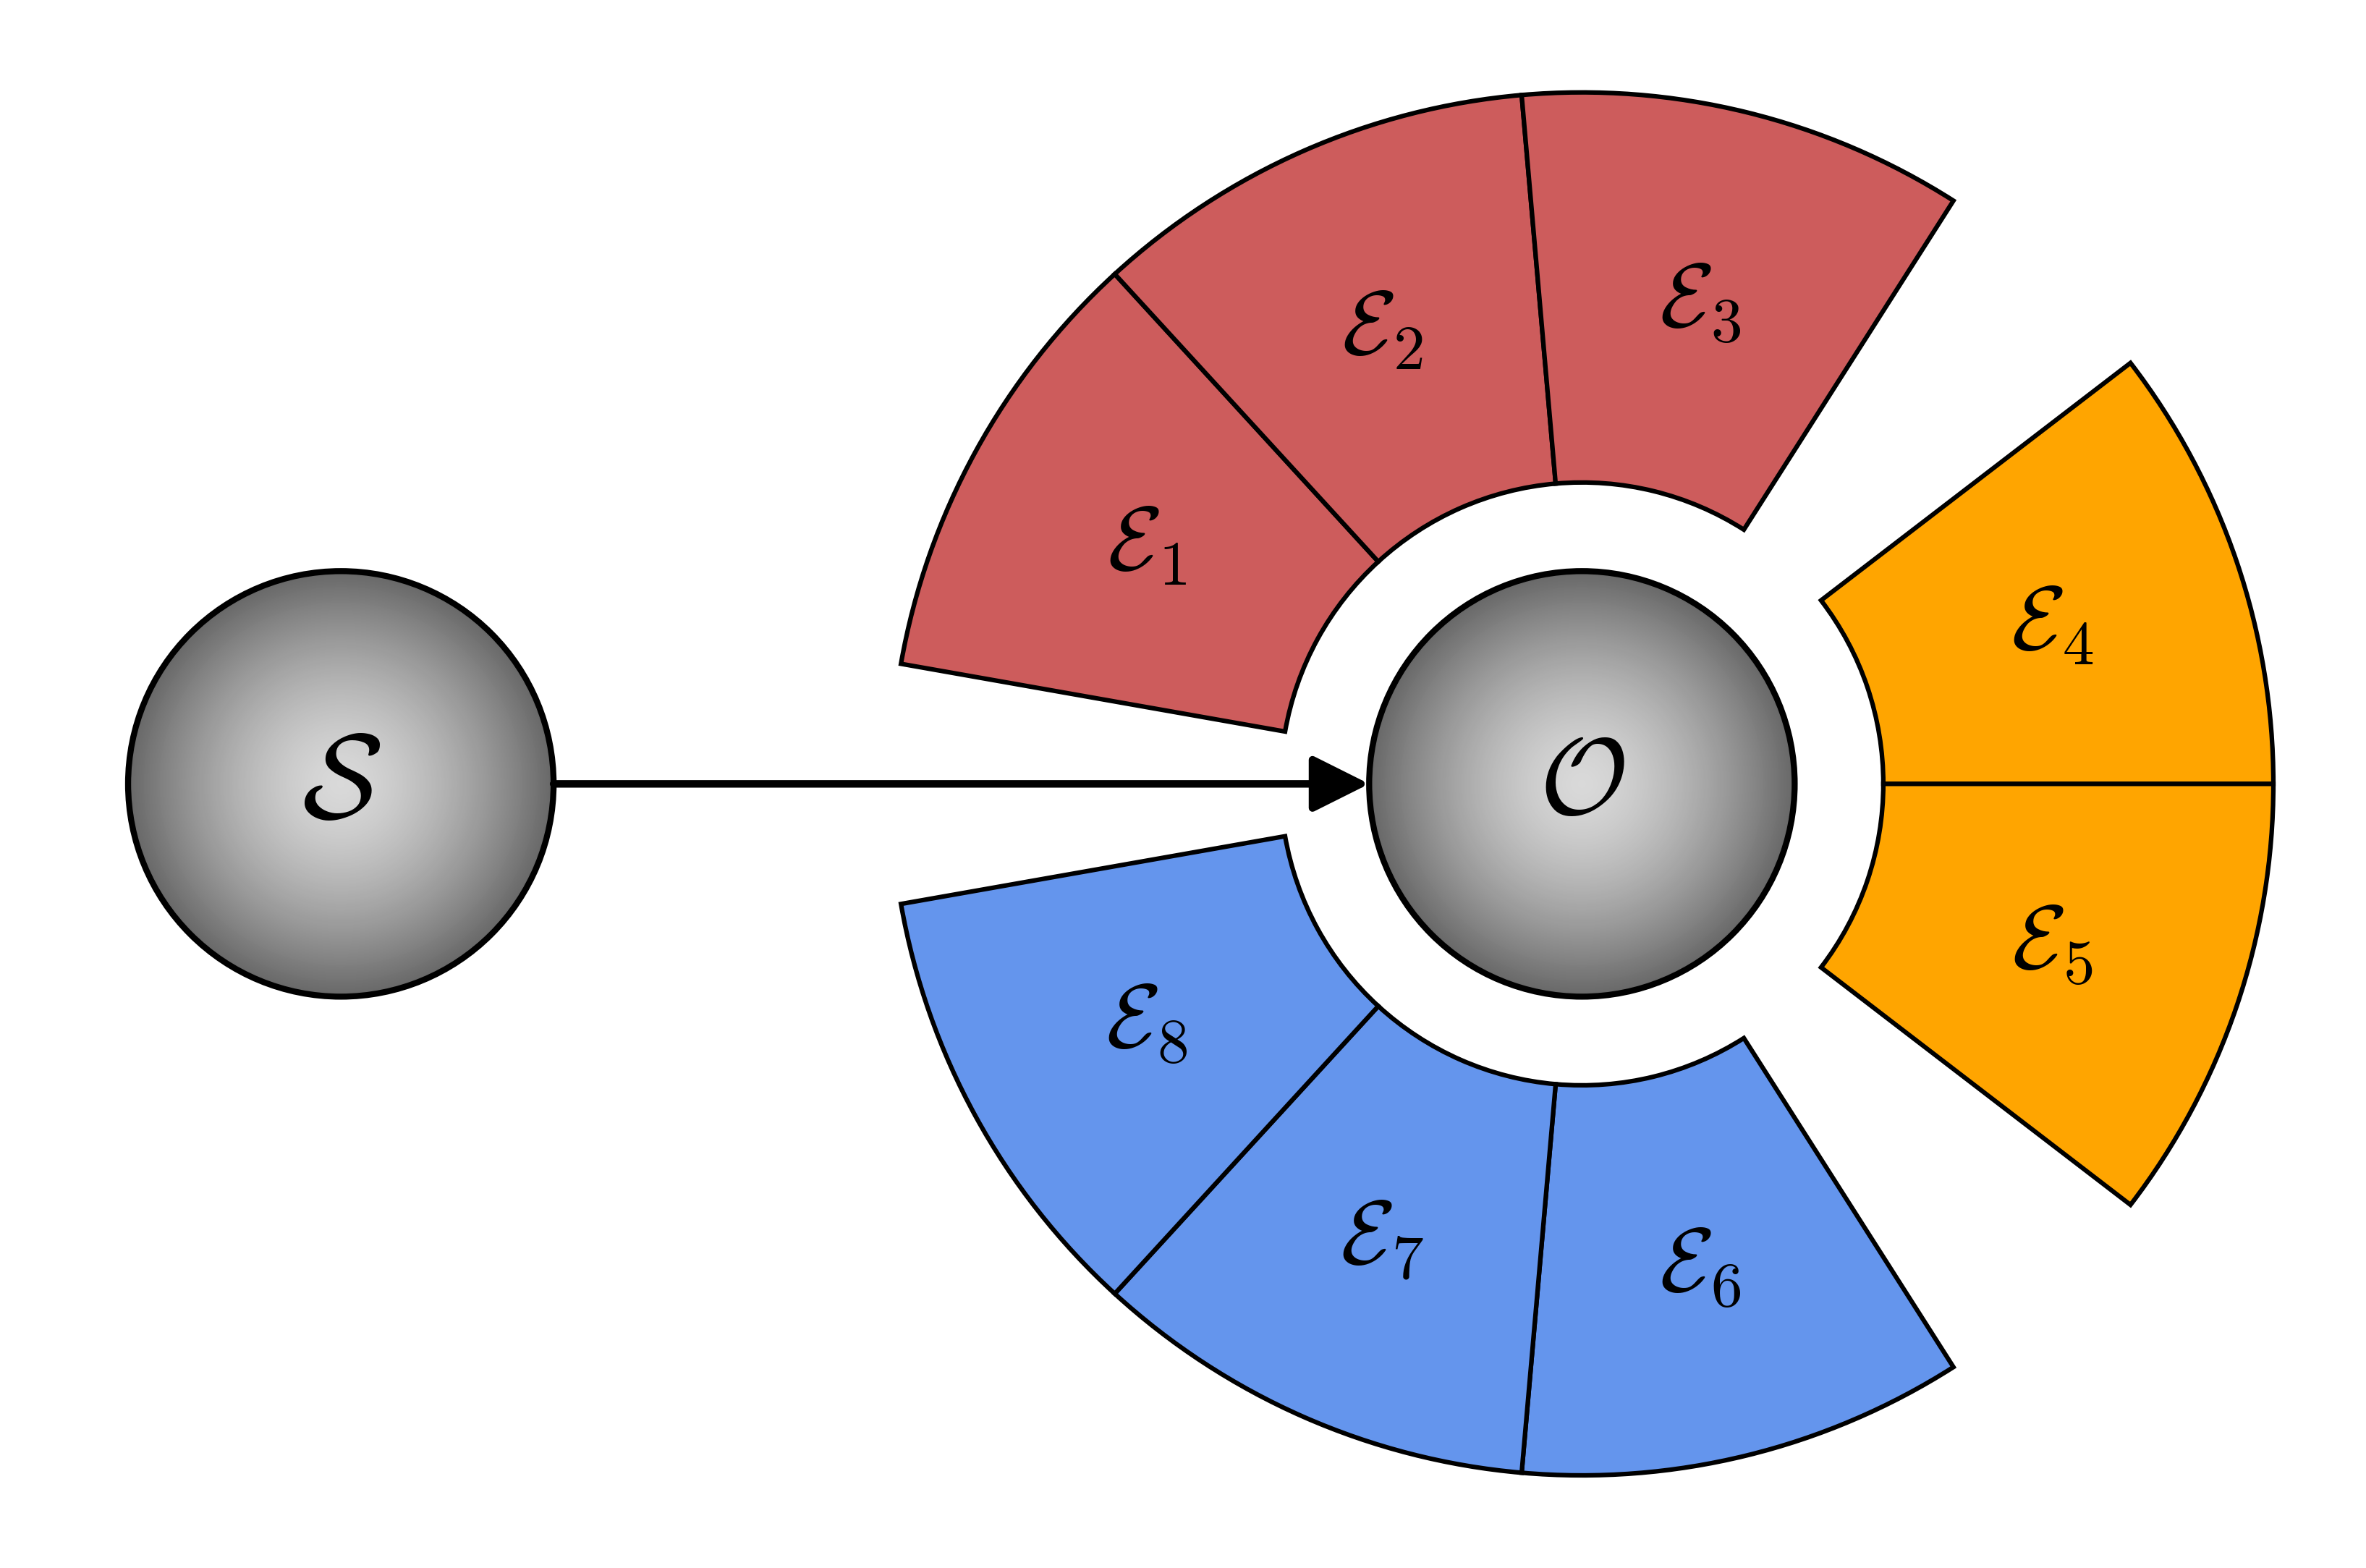

In [82]:
# QD - Wigner Picture Illustration 
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Wedge, Circle

# Cấu hình phông chữ LaTeX (Computer Modern)
plt.rcParams.update({
    'font.family': 'serif',
    'mathtext.fontset': 'cm',
    'figure.facecolor': 'white'
})

fig, ax = plt.subplots(figsize=(11, 8), dpi=300)

# ==========================================
# THIẾT LẬP KÍCH THƯỚC VÀ KHOẢNG CÁCH
# ==========================================
r_object = 0.60                      # Bán kính đối tượng O trung tâm
radial_gap = 0.25                    # Khoảng cách từ O đến môi trường E
r_inner_env = r_object + radial_gap  # Bán kính trong môi trường E
r_outer_env = 1.95                   # Bán kính ngoài môi trường E

# Cấu hình 3 CỤM MÔI TRƯỜNG E (Tổng = 8 mảnh)
clusters = [3, 2, 3]                 # Cụm 1 (Đỏ): 3 mảnh, Cụm 2 (Vàng): 2 mảnh, Cụm 3 (Xanh): 3 mảnh
cluster_gap_deg = 20                 # Góc hở (độ) giữa các cụm

# Màu sắc theo thứ tự từ trái sang phải
cluster_colors = ['indianred', 'orange', 'cornflowerblue']

total_gaps_deg = len(clusters) * cluster_gap_deg
total_fragments = sum(clusters)
slice_angle = (360 - total_gaps_deg) / total_fragments  # ~32.5 độ/mảnh

# Tọa độ vị trí cho hình tròn S (đặt bên trái, x_S < 0)
x_S, y_S = -3.5, 0.0                 # Tâm hình tròn S bên trái
r_S = 0.60                           # Bán kính hình tròn S

# ==========================================
# 1. VẼ 3 CỤM MÔI TRƯỜNG VỚI MÀU SẮC & THỨ TỰ TỪ TRÁI SANG PHẢI
# ==========================================
# Bắt đầu vẽ từ cụm đỏ ở phía trên bên trái (sau khe hở phía trái 180 độ)
# Đi theo chiều kim đồng hồ để xếp thứ tự mảnh từ trái sang phải (từ góc ~170° giảm dần về góc tiêu chuẩn)
start_angle = 180 - cluster_gap_deg / 2
current_angle = start_angle

fragment_counter = 1

for cluster_idx, num_frags in enumerate(clusters):
    current_color = cluster_colors[cluster_idx]
    
    for i in range(num_frags):
        theta1 = current_angle - slice_angle
        theta2 = current_angle
        
        # Vẽ miếng vành khăn với màu theo cụm
        wedge = Wedge(
            center=(0, 0), r=r_outer_env, theta1=theta1, theta2=theta2, 
            width=r_outer_env - r_inner_env,
            facecolor=current_color, edgecolor='black', linewidth=1.5, zorder=1
        )
        ax.add_patch(wedge)
        
        # Tính vị trí và ghi nhãn \mathcal{E}_i
        angle_mid = np.radians((theta1 + theta2) / 2)
        r_label = (r_inner_env + r_outer_env) / 2
        x_lbl = r_label * np.cos(angle_mid)
        y_lbl = r_label * np.sin(angle_mid)
        
        ax.text(
            x_lbl, y_lbl, rf'$\mathcal{{E}}_{{{fragment_counter}}}$', 
            fontsize=30, fontweight='bold', color='black',
            ha='center', va='center', zorder=4
        )
        
        current_angle -= slice_angle
        fragment_counter += 1
        
    # Tạo khe hở góc sau mỗi cụm
    current_angle -= cluster_gap_deg

# ==========================================
# 2. VẼ ĐƯỜNG NẰM NGANG NỐI S VÀ O
# ==========================================
# Mũi tên từ S tới O qua khe hở phía trái
ax.annotate('', xy=(-r_object, 0), xytext=(x_S + r_S, 0),
            arrowprops=dict(arrowstyle='- |>', mutation_scale=40, color='black',
                            lw=2.5, shrinkA=0, shrinkB=0), zorder=3)

# ==========================================
# 3. VẼ HÌNH TRÒN O VÀ S (GRADIENT XÁM 3D)
# ==========================================
def draw_gradient_circle(center_x, center_y, radius, z_base):
    N = 150
    for r in np.linspace(0, radius, N)[::-1]:
        gray_val = 0.85 - 0.45 * (r / radius)**1.5
        circle = Circle((center_x, center_y), r, color=(gray_val, gray_val, gray_val), zorder=z_base)
        ax.add_patch(circle)
    border = Circle((center_x, center_y), radius, fill=False, edgecolor='black', linewidth=2.0, zorder=z_base+1)
    ax.add_patch(border)

# Vẽ O tại gốc tọa độ (0,0)
draw_gradient_circle(0, 0, r_object, z_base=2)
ax.text(0, 0, r'$\mathcal{O}$', fontsize=36, fontstyle='italic', ha='center', va='center', zorder=5)

# Vẽ S bên trái (-3.5, 0)
draw_gradient_circle(x_S, y_S, r_S, z_base=2)
ax.text(x_S, y_S, r'$\mathcal{S}$', fontsize=40, fontstyle='italic', ha='center', va='center', zorder=5)

# ==========================================
# 4. CẤU HÌNH CỬA SỔ HÌNH VẼ
# ==========================================
ax.set_xlim(x_S - r_S - 0.3, r_outer_env + 0.2)
ax.set_ylim(-r_outer_env - 0.2, r_outer_env + 0.2)
ax.set_aspect('equal')
ax.axis('off')

plt.tight_layout()
plt.savefig(r"Figure\QD_Wigner_Illustration.eps", dpi=600, bbox_inches='tight')
plt.savefig(r"Figure\QD_Wigner_Illustration.png", dpi=600, bbox_inches='tight')
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


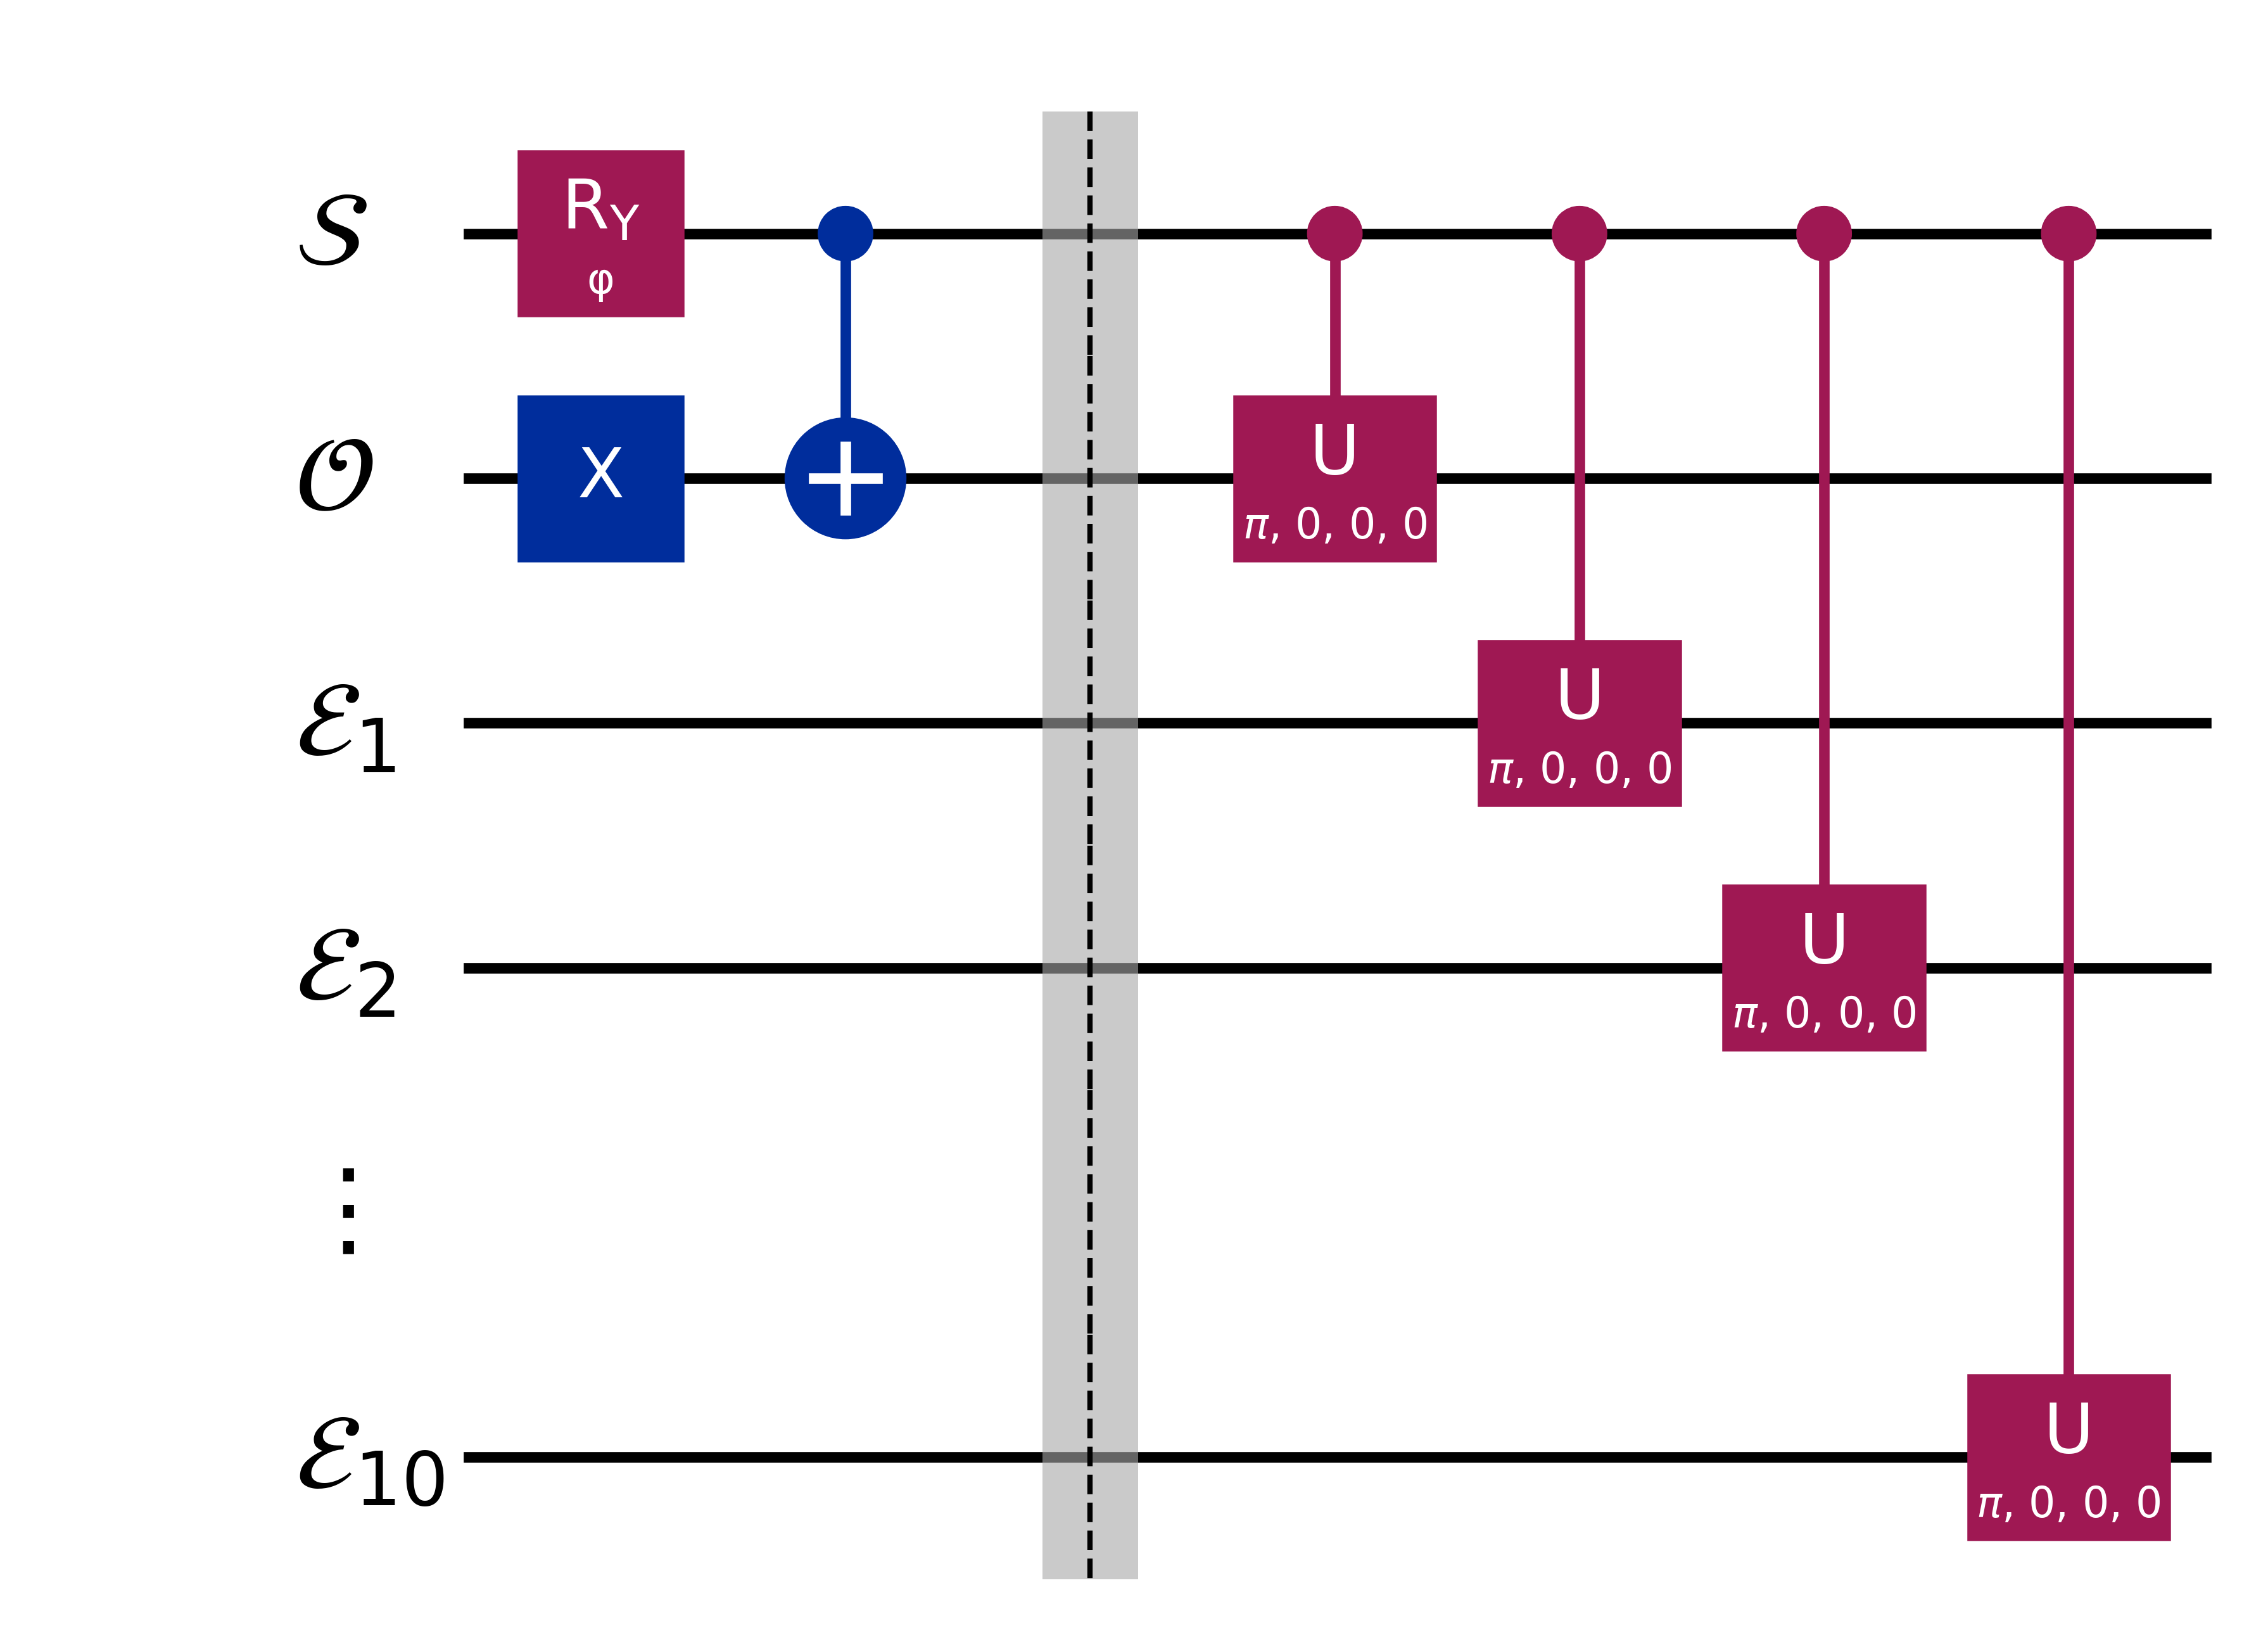

In [1]:
# QC-Wigner
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, QuantumRegister
from qiskit.circuit import Parameter
from qiskit.circuit.library import UGate

# Thiết lập độ phân giải cao cho hình ảnh
mpl.rcParams['figure.dpi'] = 600
phi = Parameter('φ')

# Khai báo các thanh ghi (giữ tên phân biệt để tránh lỗi trùng tên)
q0 = QuantumRegister(1, 'q0') # System
q1 = QuantumRegister(1, 'q1') # Observer
q2 = QuantumRegister(1, 'q2') # environment
q3 = QuantumRegister(1, 'q3')
q4 = QuantumRegister(1, 'q4')
qdots = QuantumRegister(1, 'qdots')
q12 = QuantumRegister(1, 'q12')

# Khởi tạo mạch
qc = QuantumCircuit(q0, q1, q2, q3, qdots, q12)

# Khối khởi tạo
qc.ry(phi, q0)
qc.x(q1)
qc.cx(q0, q1)
qc.barrier()

# Khối tương tác môi trường
u3_gate = UGate(np.pi, 0, 0, label="U").control(1)
qc.append(u3_gate, [q0, q1])
qc.append(u3_gate, [q0, q2])
qc.append(u3_gate, [q0, q3])
qc.append(u3_gate, [q0, q12])

# 1. Vẽ mạch từ Qiskit bằng MPL backend
fig = qc.draw(output="mpl", idle_wires=True)
ax = fig.axes[0]

# 2. Xử lý các nhãn gốc: ẩn văn bản và xóa hộp bbox
original_y_coords = []
for text in ax.texts:
    x, y = text.get_position()
    # Các nhãn qubit luôn nằm bên trái dây (x < 0)
    if x < 0:
        original_y_coords.append(y)
        # Ẩn văn bản cũ
        text.set_visible(False)
        # !!! SỬA LỖI TẠI ĐÂY !!!
        # Xóa bỏ hộp bbox mặc định để nó không đè lên chữ mới
        text.set_bbox(dict(facecolor='none', edgecolor='none', alpha=0.0))

# Sắp xếp tọa độ y thực tế từ trên xuống dưới
original_y_coords = sorted(original_y_coords, reverse=True)

# 3. Danh sách nhãn LaTeX theo đúng thứ tự: S -> E1 -> E2 -> E3 -> ⋮ -> E11
latex_labels = [
    r'$\mathcal{S}$',
    r'$\mathcal{O}$',
    r'$\mathcal{E}_1$',
    r'$\mathcal{E}_2$',
    r'$\vdots$',
    r'$\mathcal{E}_{10}$'
]

# 4. Ghi đè nhãn LaTeX mới vào đúng tọa độ y của từng dây
# Tinh chỉnh độ cao bằng y_offset nếu cần (ví dụ -0.05)
y_offset = -0.01
y_dots = original_y_coords[4]
x_offset = -0.95  # Dịch sang trái để tránh trùng với dây
for line in ax.lines:
    ydata = line.get_ydata()
    if len(ydata) > 0 and all(np.isclose(y, y_dots) for y in ydata):
        line.set_visible(False)  # Ẩn hoàn toàn wire
for y_pos, label in zip(original_y_coords, latex_labels):
    # Dấu 3 chấm đứng nhích nhẹ sang phải cho thẳng hàng với chữ E
    x_pos = x_offset if label == r'$\vdots$' else x_offset
    
    ax.text(
        x_pos, y_pos + y_offset, label,
        fontsize=20,
        ha='left', # Căn lề phải
        va='center', # Căn giữa theo chiều dọc
        color='black',
        zorder=100  # Đảm bảo chữ luôn nằm trên cùng
    )
fig.savefig(r"Figure\QC_Wigner.eps", dpi=600, bbox_inches='tight')
fig.savefig(r"Figure\QC_Wigner.png", dpi=600, bbox_inches='tight')
# Hiển thị hình
fig

In [1]:
# 3D QMI Simulation - Zurek model (11 qubits)

from qiskit import QuantumCircuit
from qiskit import quantum_info as qi
from qiskit.quantum_info import DensityMatrix, partial_trace
from qiskit.circuit.library import U3Gate
import numpy as np
import matplotlib.pyplot as plt
import os 
import pickle
from joblib import Parallel, delayed
from tqdm import tqdm

class QCircuit:    
    def __init__(self, theta, phi, n):  
        self.theta = theta   
        self.phi = phi       
        self.n = n           

    def Circuit(self): 
        qc = QuantumCircuit(self.n)
        qb_sys   = 0
        qb_envir = list(range(1, self.n))
        # System prepare |+> using Hadamard gate 
        qc.h(qb_sys)
        # System entangled with environment
        for i in qb_envir:
            cu_gate = U3Gate(self.theta, self.phi, 0).control(1)
            qc.append(cu_gate, [qb_sys, i])
        return qc 
    
    def DensityMatrix(self): 
        return qi.DensityMatrix.from_instruction(self.Circuit())  
    
    def get_reduced_dm(self, keep_qubits, rho=None):
            trace_out_qubits = [i for i in range(self.n) if i not in keep_qubits]
            
            if rho is None:
                rho = self.DensityMatrix()
            return partial_trace(rho, trace_out_qubits).data
    

class QuantumInformation(): 

    # Von Neumann entropy
    def VNE(self, state):
        eigenvalues, _ = np.linalg.eigh(state)
        eigenvalues = eigenvalues[eigenvalues > 1e-12]
        return -np.sum(eigenvalues * np.log2(eigenvalues))
    # Quantum mutual information I(S:E) = H(S) + H(E) - H(SE)
    def quantum_mutual_I(self, S_State, E_State, SE_State):
        VNE_S  = self.VNE(S_State)
        VNE_E  = self.VNE(E_State)
        VNE_SE = self.VNE(SE_State)
        return VNE_S + VNE_E - VNE_SE
    

# ================== Helper Function ==================

def compute_qmi(theta, env_qubits, numQubits, QI_calc):
    qc = QCircuit(theta, 0, numQubits)
    
    # 1. Lấy ma trận toàn phần 1 LẦN DUY NHẤT
    full_rho = qc.DensityMatrix()
    
    # 2. Dùng hàm get_reduced_dm của bạn và truyền full_rho vào
    rho_S = qc.get_reduced_dm([0], rho=full_rho)
    
    qmi_vals = []
    for i in range(len(env_qubits)):
        Ef = env_qubits[:i+1]
        
        # Gọi hàm get_reduced_dm quen thuộc của bạn
        rho_Ef   = qc.get_reduced_dm(Ef, rho=full_rho)
        rho_SEf  = qc.get_reduced_dm([0] + Ef, rho=full_rho)
        
        qmi_vals.append(QI_calc.quantum_mutual_I(rho_S, rho_Ef, rho_SEf))
        
    return qmi_vals

# ================== MAIN SIMULATION ==================
numQubits = 11
phi = 0
env_qubits = list(range(1, numQubits))  # q1..q10
QI_calc = QuantumInformation()

theta_vals = np.linspace(0, 2*np.pi, 50)   # 50 steps
fs = np.array(range(1, len(env_qubits)+1)) / len(env_qubits) * 100  # fragment size %

Theta, FS = np.meshgrid(theta_vals, fs)

# Parallel + Progress bar
results = Parallel(n_jobs=-1)(
    delayed(compute_qmi)(theta, env_qubits, numQubits, QI_calc) 
    for theta in tqdm(theta_vals, desc="Simulating QMI vs Theta")
)

QMI_matrix = np.array(results).T  # chuyển kết quả thành ma trận


# Sau khi tính xong QMI_matrix
data_to_save = {
    "FS": FS,
    "Theta": Theta,
    "QMI_matrix": QMI_matrix
}

# Lưu vào file pkl
with open("3D_QMI_Zurek.pkl", "wb") as f:
    pickle.dump(data_to_save, f)

Simulating QMI vs Theta: 100%|██████████| 50/50 [04:11<00:00,  5.03s/it] 


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


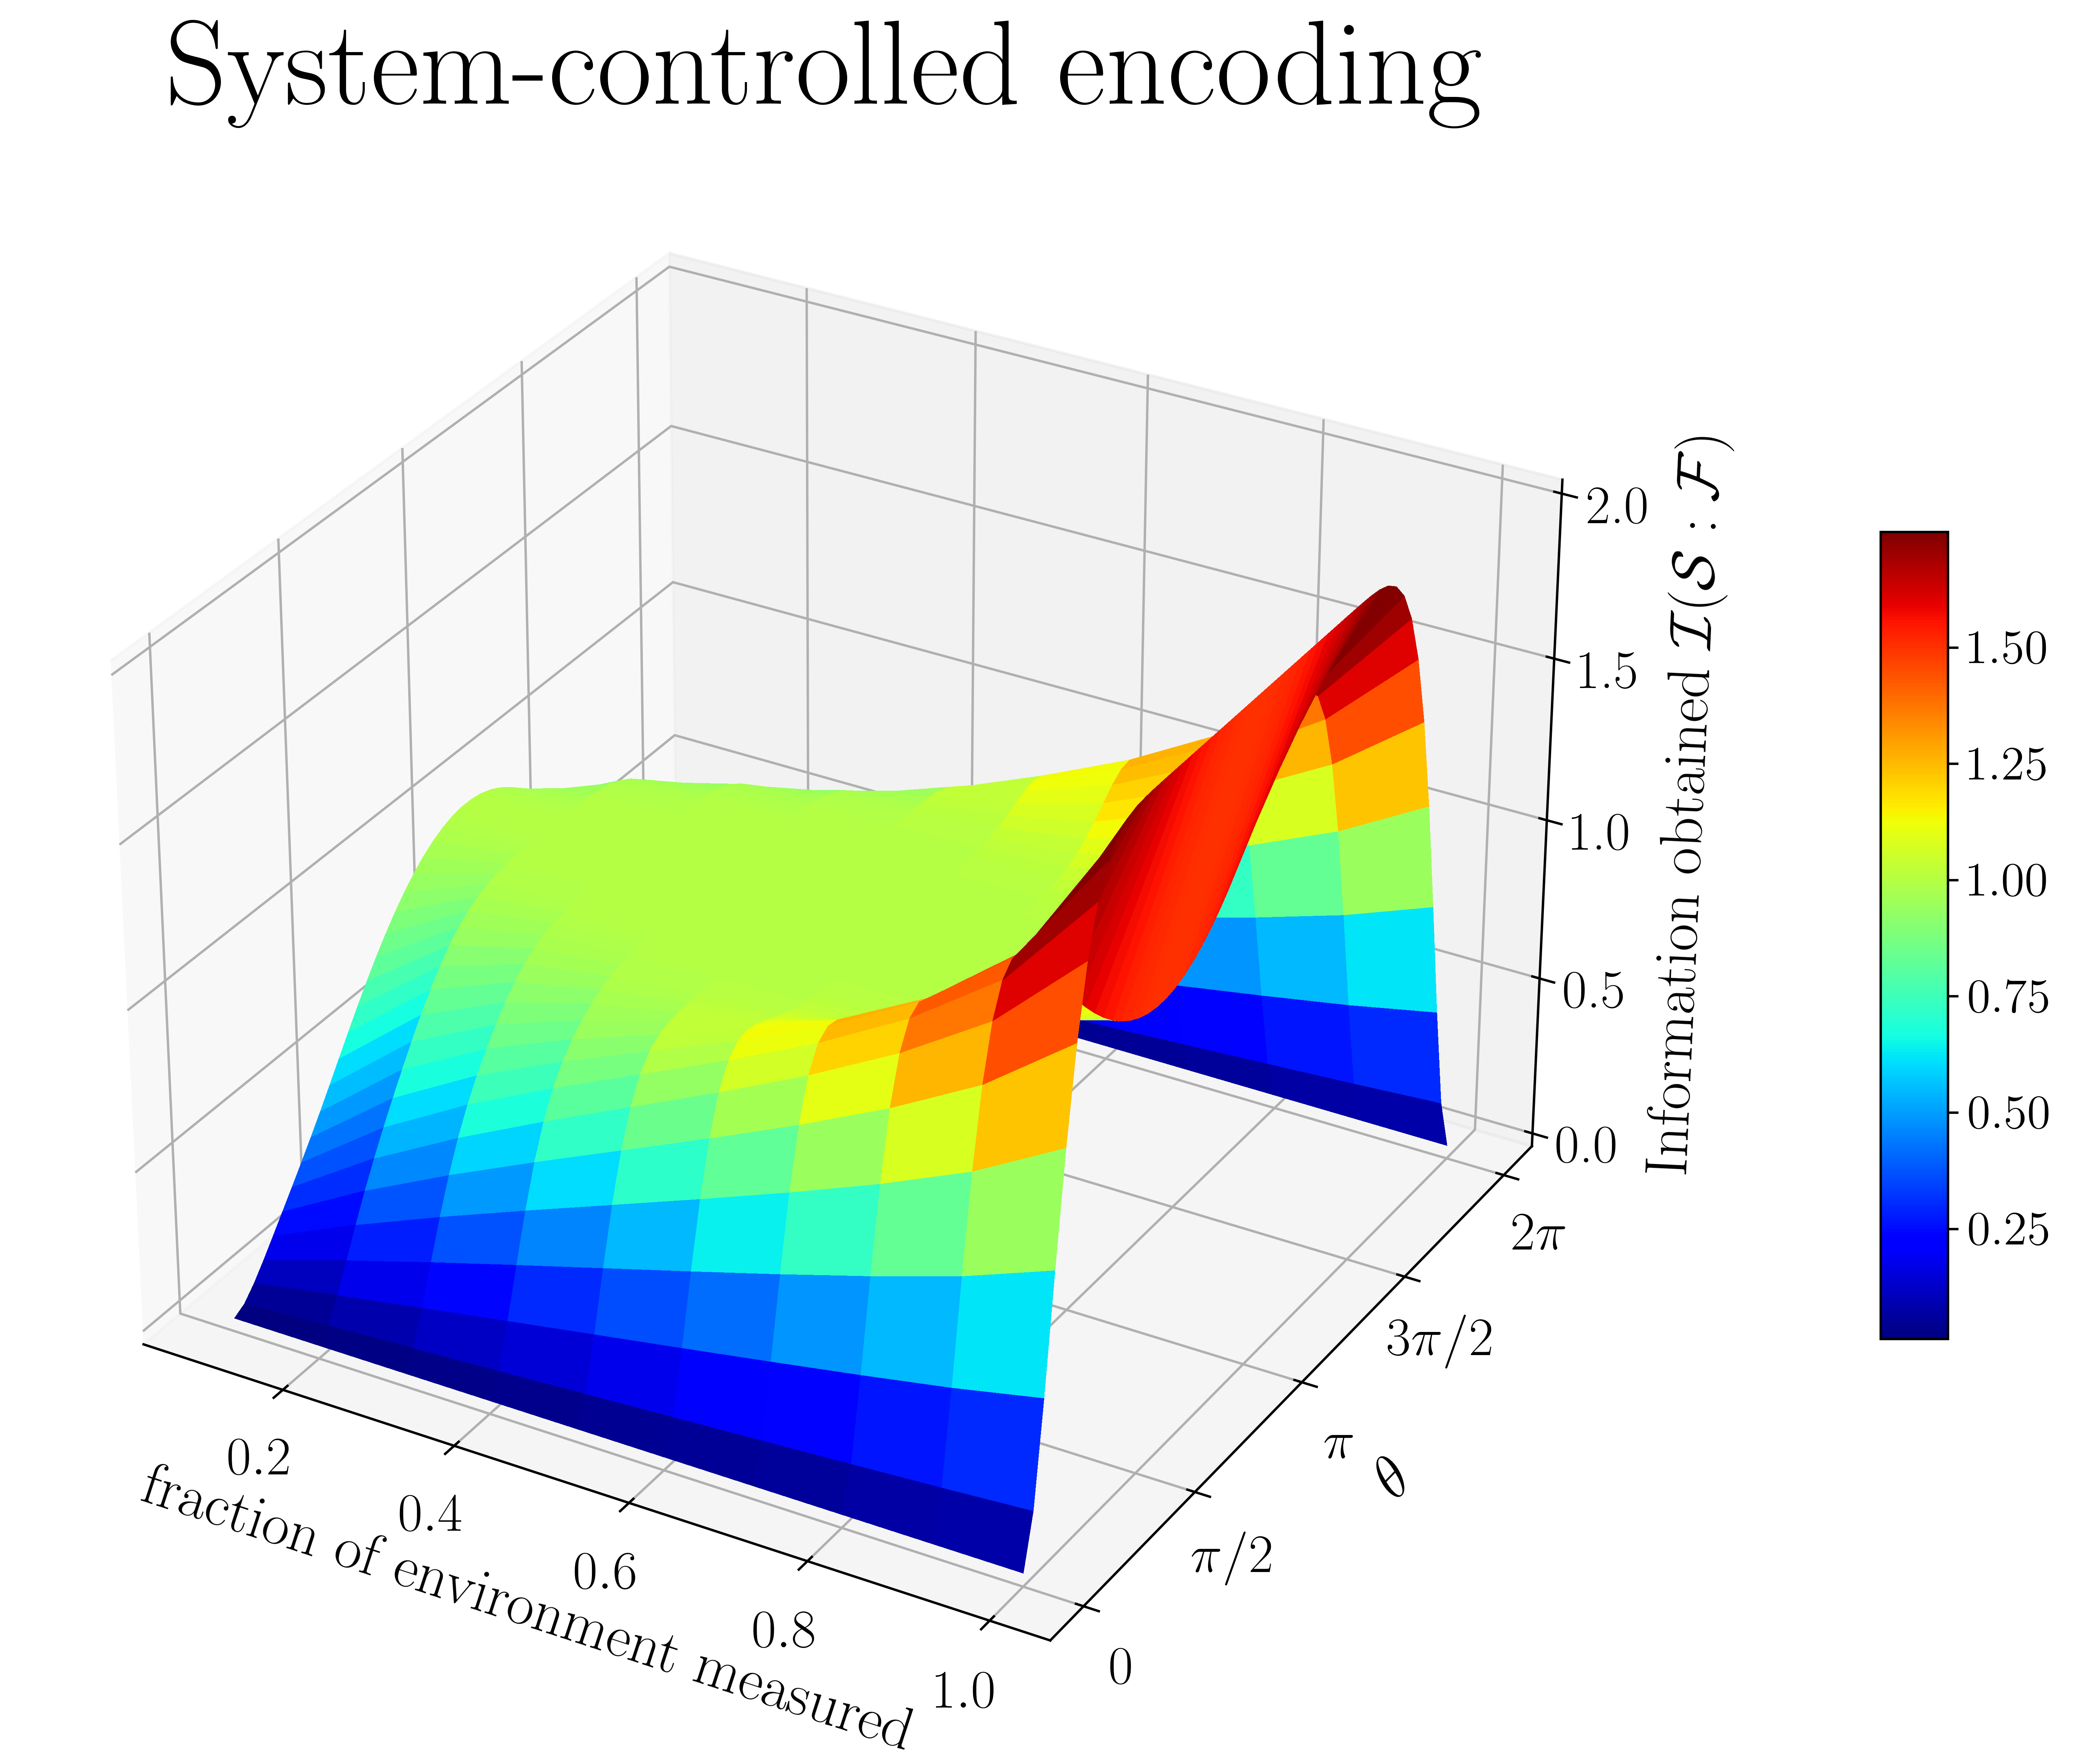

In [8]:
# PLOT Zurek model - QMI 3D Simulation
import pickle
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import os
import numpy as np
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl
import os
import pickle
import os
from IPython.display import display

os.environ["PATH"] += os.pathsep + "/Library/TeX/texbin"

mpl.rcParams['figure.dpi'] = 600
mpl.rcParams['text.usetex'] = True
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['font.serif'] = ['Computer Modern Roman']
mpl.rcParams['axes.unicode_minus'] = False
mpl.rcParams['savefig.transparent'] = False

# Load dữ liệu từ file pkl
with open("3D_QMI_Zurek.pkl", "rb") as f:
    loaded_data = pickle.load(f)

FS = loaded_data["FS"]
FS_norm = FS / 100.0
Theta = loaded_data["Theta"]
QMI_matrix = loaded_data["QMI_matrix"]

# Vẽ lại 3D plot
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(
    FS_norm, Theta, QMI_matrix, 
    cmap='jet', 
    shade=False,        # Tắt bóng mờ chứa alpha ngầm
    antialiased=False,  # Tắt khử răng cưa chứa alpha ở mép
    linewidth=0
)


ax.set_xlabel('fraction of environment measured', fontsize=20, labelpad = 8)

ax.set_ylabel(r'$\theta$', fontsize=20, labelpad=8)
ax.set_zlabel("Information obtained " + r'$\mathcal{I}(\mathcal{S}:\mathcal{F})$', 
              fontsize=20, labelpad=8)
# Chỉnh ticks cho trục z
ax.set_zticks([0.0, 0.5, 1.0, 1.5, 2.0])
ax.set_zticklabels(['0.0', '0.5', '1.0', '1.5', '2.0'])



ax.set_title('System-controlled encoding', fontsize=40, ha = 'center')


ax.set_yticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi])
ax.set_yticklabels(['0', r'$\pi/2$', r'$\pi$', r'$3\pi/2$', r'$2\pi$'])



ax.tick_params(axis='x', labelsize=18, width=2.5)
ax.tick_params(axis='y', labelsize=18, width=2.5)
ax.tick_params(axis='z', labelsize=18, width=2.5)

cbar = fig.colorbar(surf, shrink=0.5, aspect=12, pad=0.1)
cbar.ax.tick_params(labelsize=16)  # chỉnh size chữ số

fig.subplots_adjust(right=0.95, bottom=0.02, top=0.95, left=0.01)
for artist in fig.get_children():
    if hasattr(artist, 'set_alpha'):
        artist.set_alpha(1.0)


fig.savefig(r"Figure\3D_QMI_Zurek.png", dpi=600, bbox_inches='tight')
fig.savefig(r"Figure\3D_QMI_Zurek.eps", dpi=600, bbox_inches='tight')
plt.show()



In [ ]:
# Zurek model - QMI & Holevo & Discord
from qiskit import QuantumCircuit
from qiskit import quantum_info as qi
from qiskit.quantum_info import DensityMatrix, partial_trace
from qiskit.circuit.library import U3Gate
import numpy as np
import matplotlib.pyplot as plt
import pickle
import os
from qiskit import qpy

class QCircuit:    
    def __init__(self, theta, phi, n):  
        self.theta = theta   
        self.phi = phi       
        self.n = n           

    def Circuit(self): 
        qc = QuantumCircuit(self.n)
        qb_sys   = 0
        qb_envir = list(range(1, self.n))
        # System prepare |+> using Hadamard gate 
        qc.h(qb_sys)
        # System entangled with environment
        for i in qb_envir:
            cu_gate = U3Gate(self.theta, self.phi, 0).control(1)
            qc.append(cu_gate, [qb_sys, i])
        return qc 
    
    def DensityMatrix(self): 
        return qi.DensityMatrix.from_instruction(self.Circuit())  
    
    def get_reduced_dm(self, keep_qubits):
        trace_out_qubits = [i for i in range(self.n) if i not in keep_qubits]
        rho = self.DensityMatrix()
        return partial_trace(rho, trace_out_qubits).data

class QuantumInformation(): 

    # Von Neumann entropy
    def VNE(self, state):
        eigenvalues, _ = np.linalg.eigh(state)
        eigenvalues = eigenvalues[eigenvalues > 1e-12]
        return -np.sum(eigenvalues * np.log2(eigenvalues))
    
    # Quantum mutual information I(S:E) = H(S) + H(E) - H(SE)
    def quantum_mutual_I(self, S_State, E_State, SE_State):
        VNE_S  = self.VNE(S_State)
        VNE_E  = self.VNE(E_State)
        VNE_SE = self.VNE(SE_State)
        return VNE_S + VNE_E - VNE_SE
   
    # Holevo Bound χ(S:F) = S(E) - Σ p_i S(E|i) 
    def HolevoBound(self, rho_SEf, rho_S):
            
            rho_Ef = partial_trace(DensityMatrix(rho_SEf), [0]).data
            S_Ef = self.VNE(rho_Ef)
            
            sum_cond_entropy = 0
            d_Ef = rho_SEf.shape[0] // 2  # Chỉ cần dòng này là đủ, vừa sạch code vừa chạy nhanh
            
            # pointer basis of system S
            proj_0 = np.array([[1, 0], [0, 0]], dtype=complex)
            proj_1 = np.array([[0, 0], [0, 1]], dtype=complex)
            computational_projections = [proj_0, proj_1]
            
            for proj_S in computational_projections:

                proj_SEf = np.kron(np.eye(d_Ef, dtype=complex), proj_S)

                # probability of outcome i of POVM \Pi_S on System
                p_i = np.real(np.trace(proj_SEf @ rho_SEf))
                
                if p_i > 1e-12:
                    rho_SEf_i = (proj_SEf @ rho_SEf @ proj_SEf) / p_i
                    rho_Ef_i = partial_trace(DensityMatrix(rho_SEf_i), [0]).data
                    sum_cond_entropy += p_i * self.VNE(rho_Ef_i)
                    
            return S_Ef - sum_cond_entropy
    
    # Quantum Discord D(S:F) = I(S:F) - χ(S:F) 
    def quantum_discord(self, rho_SE, rho_S):
        rho_E = partial_trace(DensityMatrix(rho_SE), [0]).data
        I_AB = self.quantum_mutual_I(rho_S, rho_E, rho_SE)
        
        cond_entropy = 0
        d_E = rho_SE.shape[0] // 2  # Đồng bộ hệ S kích thước 2
        
        # Pointer basis giống y hệt HolevoBound
        proj_0 = np.array([[1, 0], [0, 0]], dtype=complex)
        proj_1 = np.array([[0, 0], [0, 1]], dtype=complex)
        pointer_projections = [proj_0, proj_1]
        
        for proj_S in pointer_projections:
            # Sửa lại thứ tự kron để khớp với quy ước Qiskit Little-Endian
            proj_SE = np.kron(np.eye(d_E, dtype=complex), proj_S) 
            
            p_i = np.real(np.trace(proj_SE @ rho_SE))
            if p_i > 1e-12:
                rho_SE_i = (proj_SE @ rho_SE @ proj_SE) / p_i
                rho_B_i = partial_trace(DensityMatrix(rho_SE_i), [0]).data
                cond_entropy += p_i * self.VNE(rho_B_i)
        
        S_B = self.VNE(rho_E)
        classical_corr = S_B - cond_entropy
        return I_AB - classical_corr
    
# ========== MAIN ==========
numQubits = 11 # q0 system, q1..q10 environment
theta, phi = np.pi, 0
qc = QCircuit(theta, phi, numQubits)
QI_calc = QuantumInformation()

rho_S = qc.get_reduced_dm([0])
env_qubits = list(range(1, numQubits))

results_S_Envir, results_Discord, results_Holevo = [], [], []

for k in range(1, len(env_qubits)+1):

    Ef = env_qubits[:k]
    rho_Ef   = qc.get_reduced_dm(Ef)
    rho_SEf  = qc.get_reduced_dm([0]+Ef)

    # QMI
    QMI_S_Ef = QI_calc.quantum_mutual_I(rho_S, rho_Ef, rho_SEf)
    results_S_Envir.append(QMI_S_Ef)
    # Holevo
    Holevo_Ef = QI_calc.HolevoBound(rho_SEf, rho_S)
    results_Holevo.append(Holevo_Ef)
    # Quantum Discord
    Discord_S_Ef = QI_calc.quantum_discord(rho_SEf, rho_S)
    results_Discord.append(Discord_S_Ef)

qcircuit_obj = qc.Circuit()

rho_E_full  = qc.get_reduced_dm(env_qubits)

rho_SE_full = qc.get_reduced_dm([0]+env_qubits)

QMI_S_Efull = QI_calc.quantum_mutual_I(rho_S, rho_E_full, rho_SE_full)

Holevo_E_full = QI_calc.HolevoBound(rho_SE_full, rho_S)

Discord_SE_full = QI_calc.quantum_discord(rho_SE_full, rho_S)

# ===================== SAVING ====================

data = {
    "results_S_Envir": results_S_Envir,
    "results_Holevo": results_Holevo,
    "results_Discord": results_Discord,
    "QMI_S_Efull": QMI_S_Efull,
    "Holevo_E_full": Holevo_E_full,
    "Discord_SE_full": Discord_SE_full,
    "qcircuit_obj": qcircuit_obj
}

with open("QMI_Holevo_Discord_Zurek.pkl", "wb") as f:
    pickle.dump(data, f)

print("="*50)
print(f"Saved QMI_Holevo_Discord_Zurek.pkl to the working directory: {os.getcwd()}")
print("="*50)


Saved QMI_Holevo_Discord_Zurek.pkl to the working directory: d:\Quantum Darwinism Macbook project\Quantum-Darwinism


<module 'matplotlib.pyplot' from 'c:\\Program Files\\Python310\\lib\\site-packages\\matplotlib\\pyplot.py'>

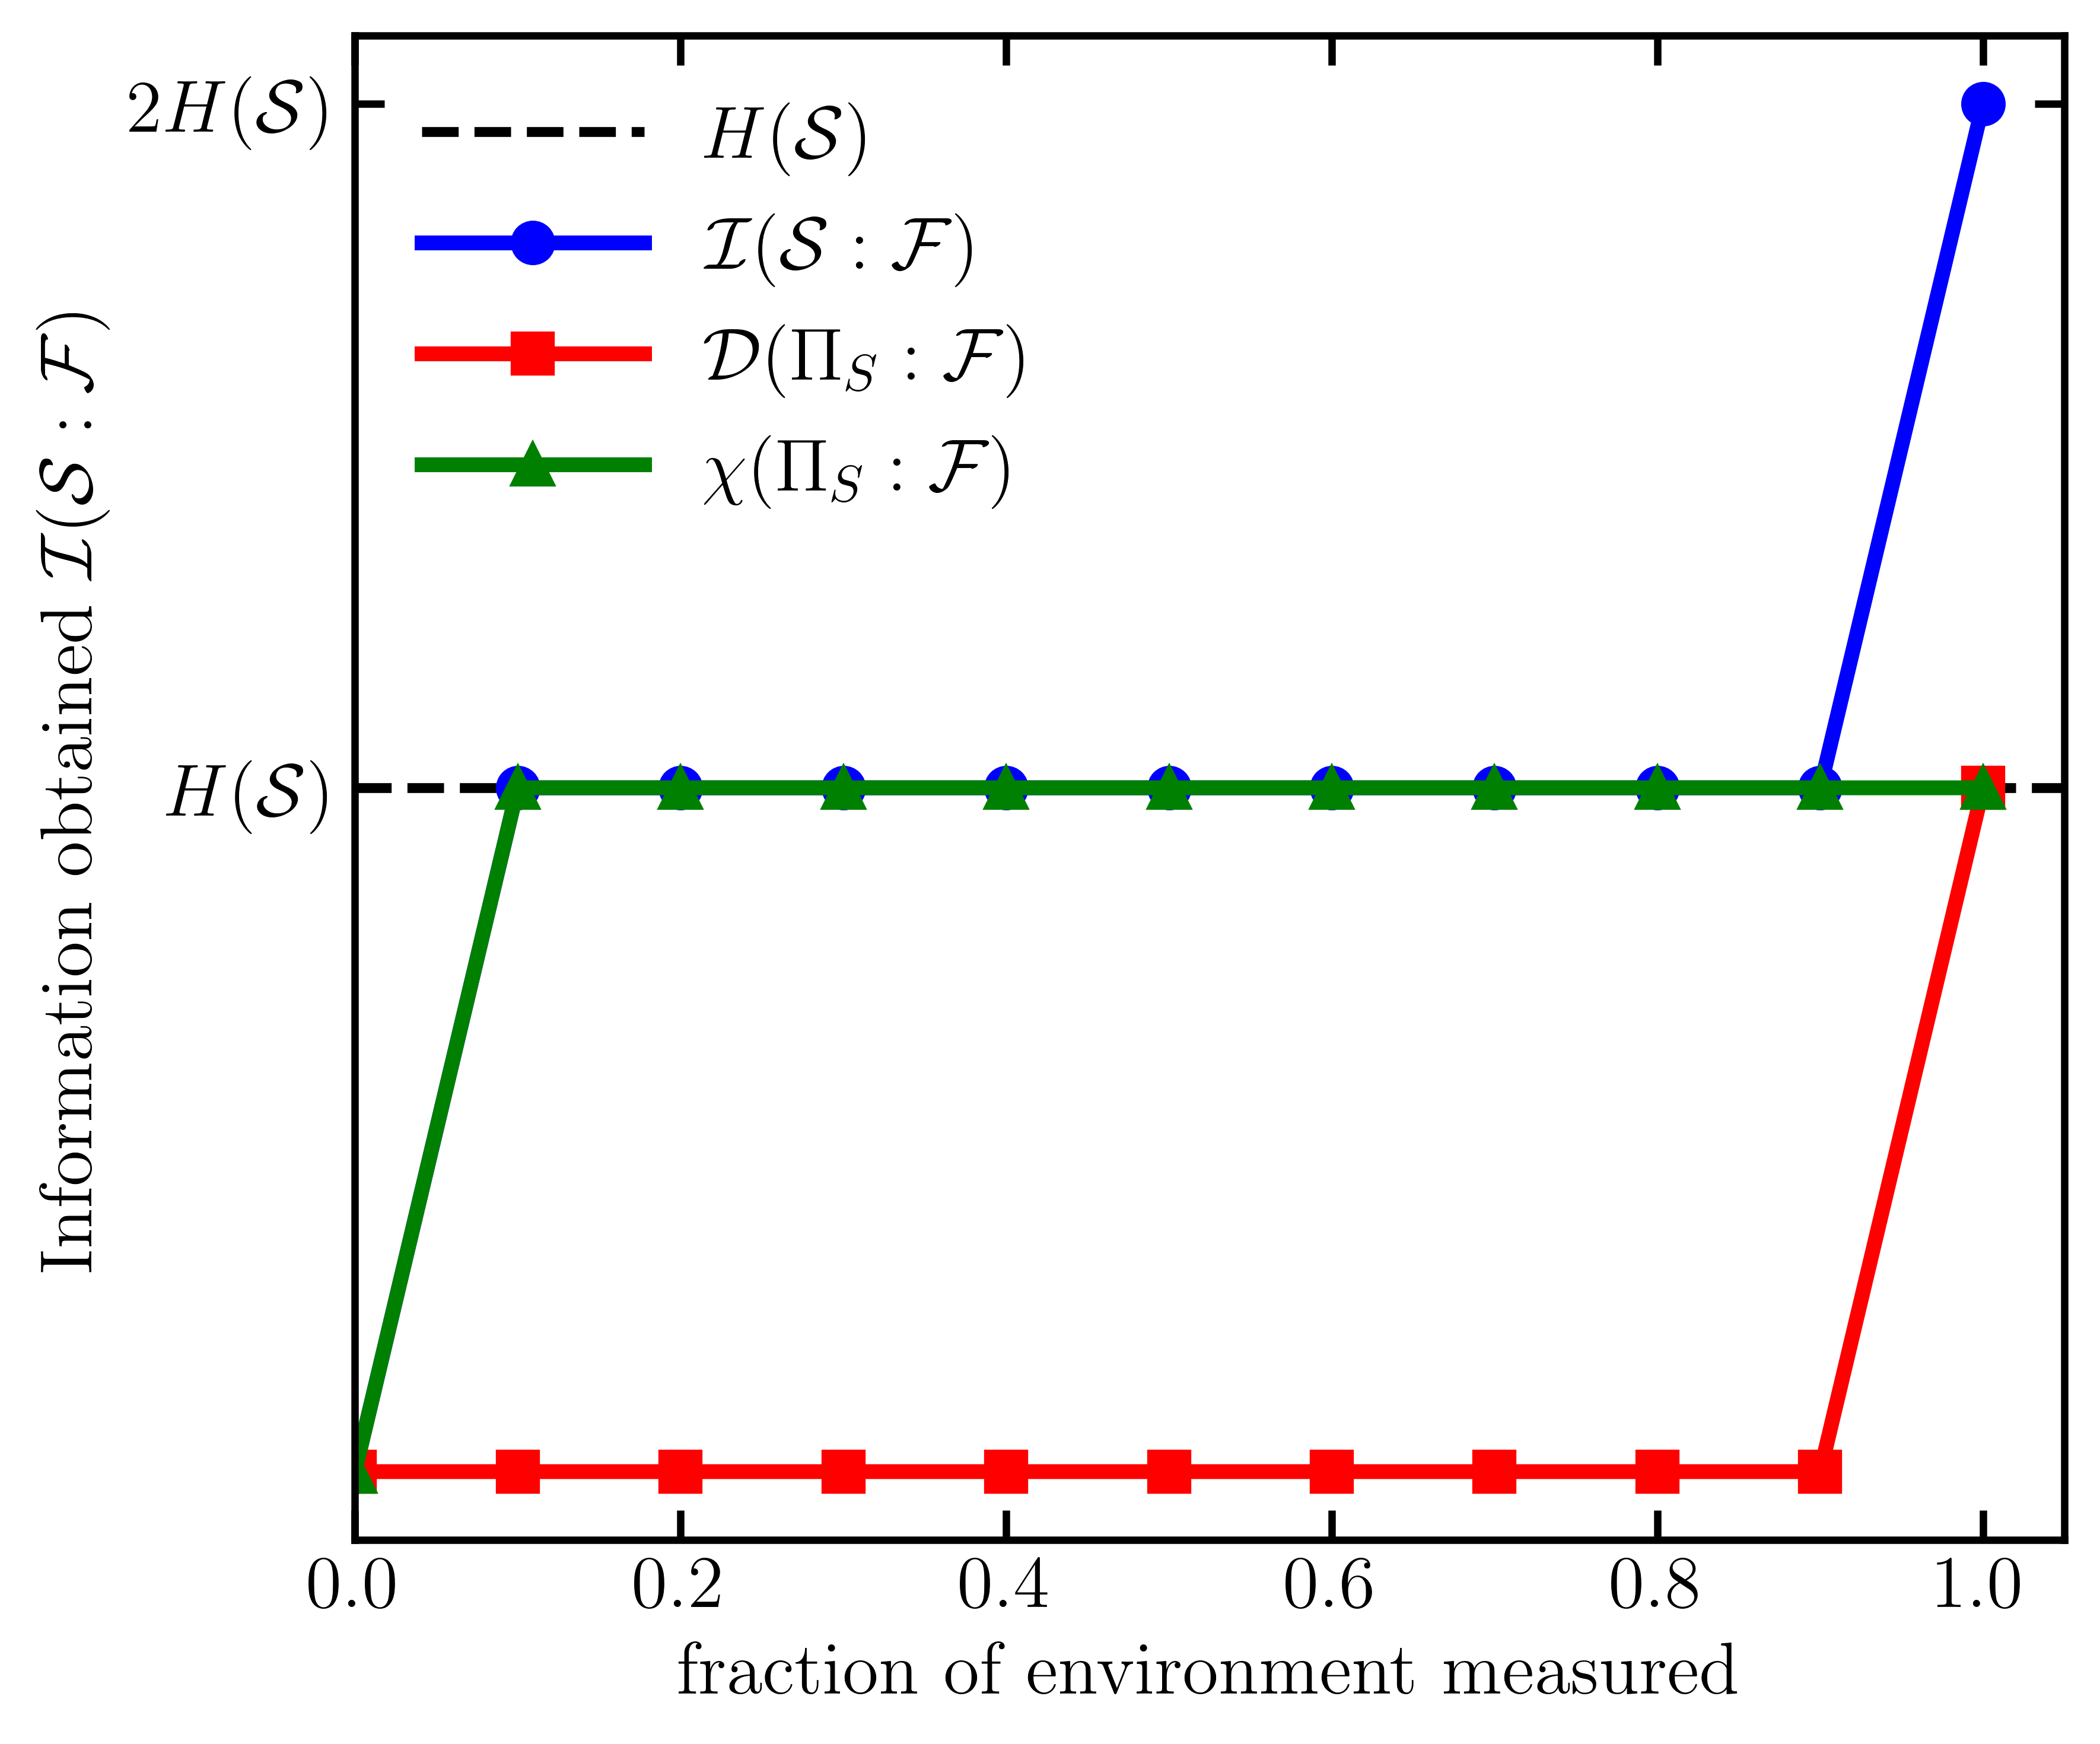

In [1]:
# PLOT Zurek model - QMI & Holevo & Discord for theta = pi

import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl
import os
import pickle
import os
from IPython.display import display

os.environ["PATH"] += os.pathsep + "/Library/TeX/texbin"

mpl.rcParams['figure.dpi'] = 600
mpl.rcParams['text.usetex'] = True
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['font.serif'] = ['Computer Modern Roman']
mpl.rcParams['axes.unicode_minus'] = False

# Working directory

with open("QMI_Holevo_Discord_Zurek.pkl", "rb") as f:
    data = pickle.load(f)

results_S_Envir = data["results_S_Envir"]
results_Holevo = data["results_Holevo"]
results_Discord = data["results_Discord"]

numQubits = 11
env_qubits = list(range(1, numQubits))

plt.figure(figsize=(6,5))
fs = np.array(range(1, len(env_qubits)+1)) / len(env_qubits)   # từ 0 đến 1
fs_ext = np.concatenate([[0], fs])

results_ext = np.concatenate([[0.0], results_S_Envir])
discord_ext = np.concatenate([[0.0], results_Discord])
holevo_ext = np.concatenate([[0.0], results_Holevo])

plt.axhline(1.0, color='black', linestyle='--', linewidth=2,
            label=r"$H(\mathcal{S})$")

plt.plot(fs_ext, results_ext, 'b-o', linewidth=3, markersize=8,
         label=r"$\mathcal{I}(\mathcal{S}:\mathcal{F})$")

plt.plot(fs_ext, discord_ext, 'r-s', linewidth=3, markersize=8,
         label=r"$\mathcal{D}(\Pi_{S}:\mathcal{F})$")

plt.plot(fs_ext, holevo_ext, 'g-^', linewidth=3, markersize=8,
         label=r"$\chi(\Pi_S:\mathcal{F})$")


ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(1.5)
ax.tick_params(width=1.5, length=6, direction="in", top=True, right=True)

yticks = [1.0, 2.0]
labels = [r"$H(\mathcal{S})$", r"$2H(\mathcal{S})$"]
plt.yticks(yticks, labels, fontsize = 15)
plt.xticks(fontsize=15)
plt.xlabel('fraction of environment measured', fontsize=15)
plt.ylabel('Information obtained ' + r'$\mathcal{I}(\mathcal{S}:\mathcal{F})$', fontsize=15)
plt.title('', fontsize=15, fontweight='bold')
plt.legend(fontsize=15, frameon=False, loc='best', handlelength=3)
plt.grid(False)
plt.xlim(0, 1.05)
plt.tight_layout()



plt.savefig(r"Figure\QMI_Holevo_Discord_Zurek.png", dpi=600, bbox_inches='tight')
plt.savefig(r"Figure\QMI_Holevo_Discord_Zurek.eps", dpi=600, bbox_inches='tight')

display(plt)


In [2]:
# 3D QMI Simulation - Wigner model (12 qubits)

from qiskit import QuantumCircuit
from qiskit import quantum_info as qi
from qiskit.quantum_info import DensityMatrix, partial_trace
from qiskit.circuit.library import U3Gate
import numpy as np
import matplotlib.pyplot as plt
import os 
import pickle
from joblib import Parallel, delayed
from tqdm import tqdm

class QCircuit:    
    def __init__(self, theta, phi_sys, phi_env, n):  
        self.theta = theta        # góc cho controlled-U3
        self.phi_sys = phi_sys    # góc quay Ry của hệ thống
        self.phi_env = phi_env    # góc cho controlled-U3
        self.n = n        

    def Circuit(self): 
        qc = QuantumCircuit(self.n)
        qb_sys   = 0
        qb_obser =1
        qb_envir = list(range(2, self.n))
        # System 
        qc.ry(self.phi_sys, qb_sys)
        qc.x(qb_obser)
        qc.cx(qb_sys, qb_obser)
        qc.barrier()
        # System entangled with environment
        for i in qb_envir:
            cu_gate = U3Gate(self.theta, self.phi_env, 0).control(1)
            qc.append(cu_gate, [qb_sys, i])
        return qc 
    

    def DensityMatrix(self): 
        return qi.DensityMatrix.from_instruction(self.Circuit())  
    
    def get_reduced_dm(self, keep_qubits, rho=None):
            trace_out_qubits = [i for i in range(self.n) if i not in keep_qubits]
            
            if rho is None:
                rho = self.DensityMatrix()
            return partial_trace(rho, trace_out_qubits).data
    

class QuantumInformation(): 

    # Von Neumann entropy
    def VNE(self, state):
        eigenvalues, _ = np.linalg.eigh(state)
        eigenvalues = eigenvalues[eigenvalues > 1e-12]
        return -np.sum(eigenvalues * np.log2(eigenvalues))
    # Quantum mutual information I(S:E) = H(S) + H(E) - H(SE)
    def quantum_mutual_I(self, S_State, E_State, SE_State):
        VNE_S  = self.VNE(S_State)
        VNE_E  = self.VNE(E_State)
        VNE_SE = self.VNE(SE_State)
        return VNE_S + VNE_E - VNE_SE
    

# ================== Helper Function ==================

def compute_qmi(theta, phi_sys, phi_env, env_qubits, numQubits, QI_calc):
    qc = QCircuit(theta, phi_sys, phi_env, numQubits)
    full_rho = qc.DensityMatrix()
    rho_S = qc.get_reduced_dm([0], rho=full_rho)
    qmi_vals = []
    for i in range(len(env_qubits)):
        Ef = env_qubits[:i+1]
        rho_Ef  = qc.get_reduced_dm(Ef, rho=full_rho)
        rho_SEf = qc.get_reduced_dm([0] + Ef, rho=full_rho)
        qmi_vals.append(QI_calc.quantum_mutual_I(rho_S, rho_Ef, rho_SEf))
    return qmi_vals


# ================== MAIN SIMULATION ==================
numQubits = 11
theta = np.pi       # cố định
phi_env = 0         # cố định
env_qubits = list(range(2, numQubits))
QI_calc = QuantumInformation()

phi_sys_vals = np.linspace(0, 2*np.pi, 50)   # vary phi_sys
fs = np.array(range(1, len(env_qubits)+1)) / len(env_qubits) * 100

PhiSys, FS = np.meshgrid(phi_sys_vals, fs)

# Parallel + Progress bar
results = Parallel(n_jobs=-1)(
    delayed(compute_qmi)(theta, phi_sys, phi_env, env_qubits, numQubits, QI_calc) 
    for phi_sys in tqdm(phi_sys_vals, desc="Simulating QMI vs phi_sys")
)

QMI_matrix = np.array(results).T



# Sau khi tính xong QMI_matrix
data_to_save = {
    "FS": FS,
    "Phi_sys": PhiSys,
    "QMI_matrix": QMI_matrix
}

# Lưu vào file pkl
with open("3D_QMI_Wigner.pkl", "wb") as f:
    pickle.dump(data_to_save, f)

Simulating QMI vs phi_sys: 100%|██████████| 50/50 [00:49<00:00,  1.01it/s]


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


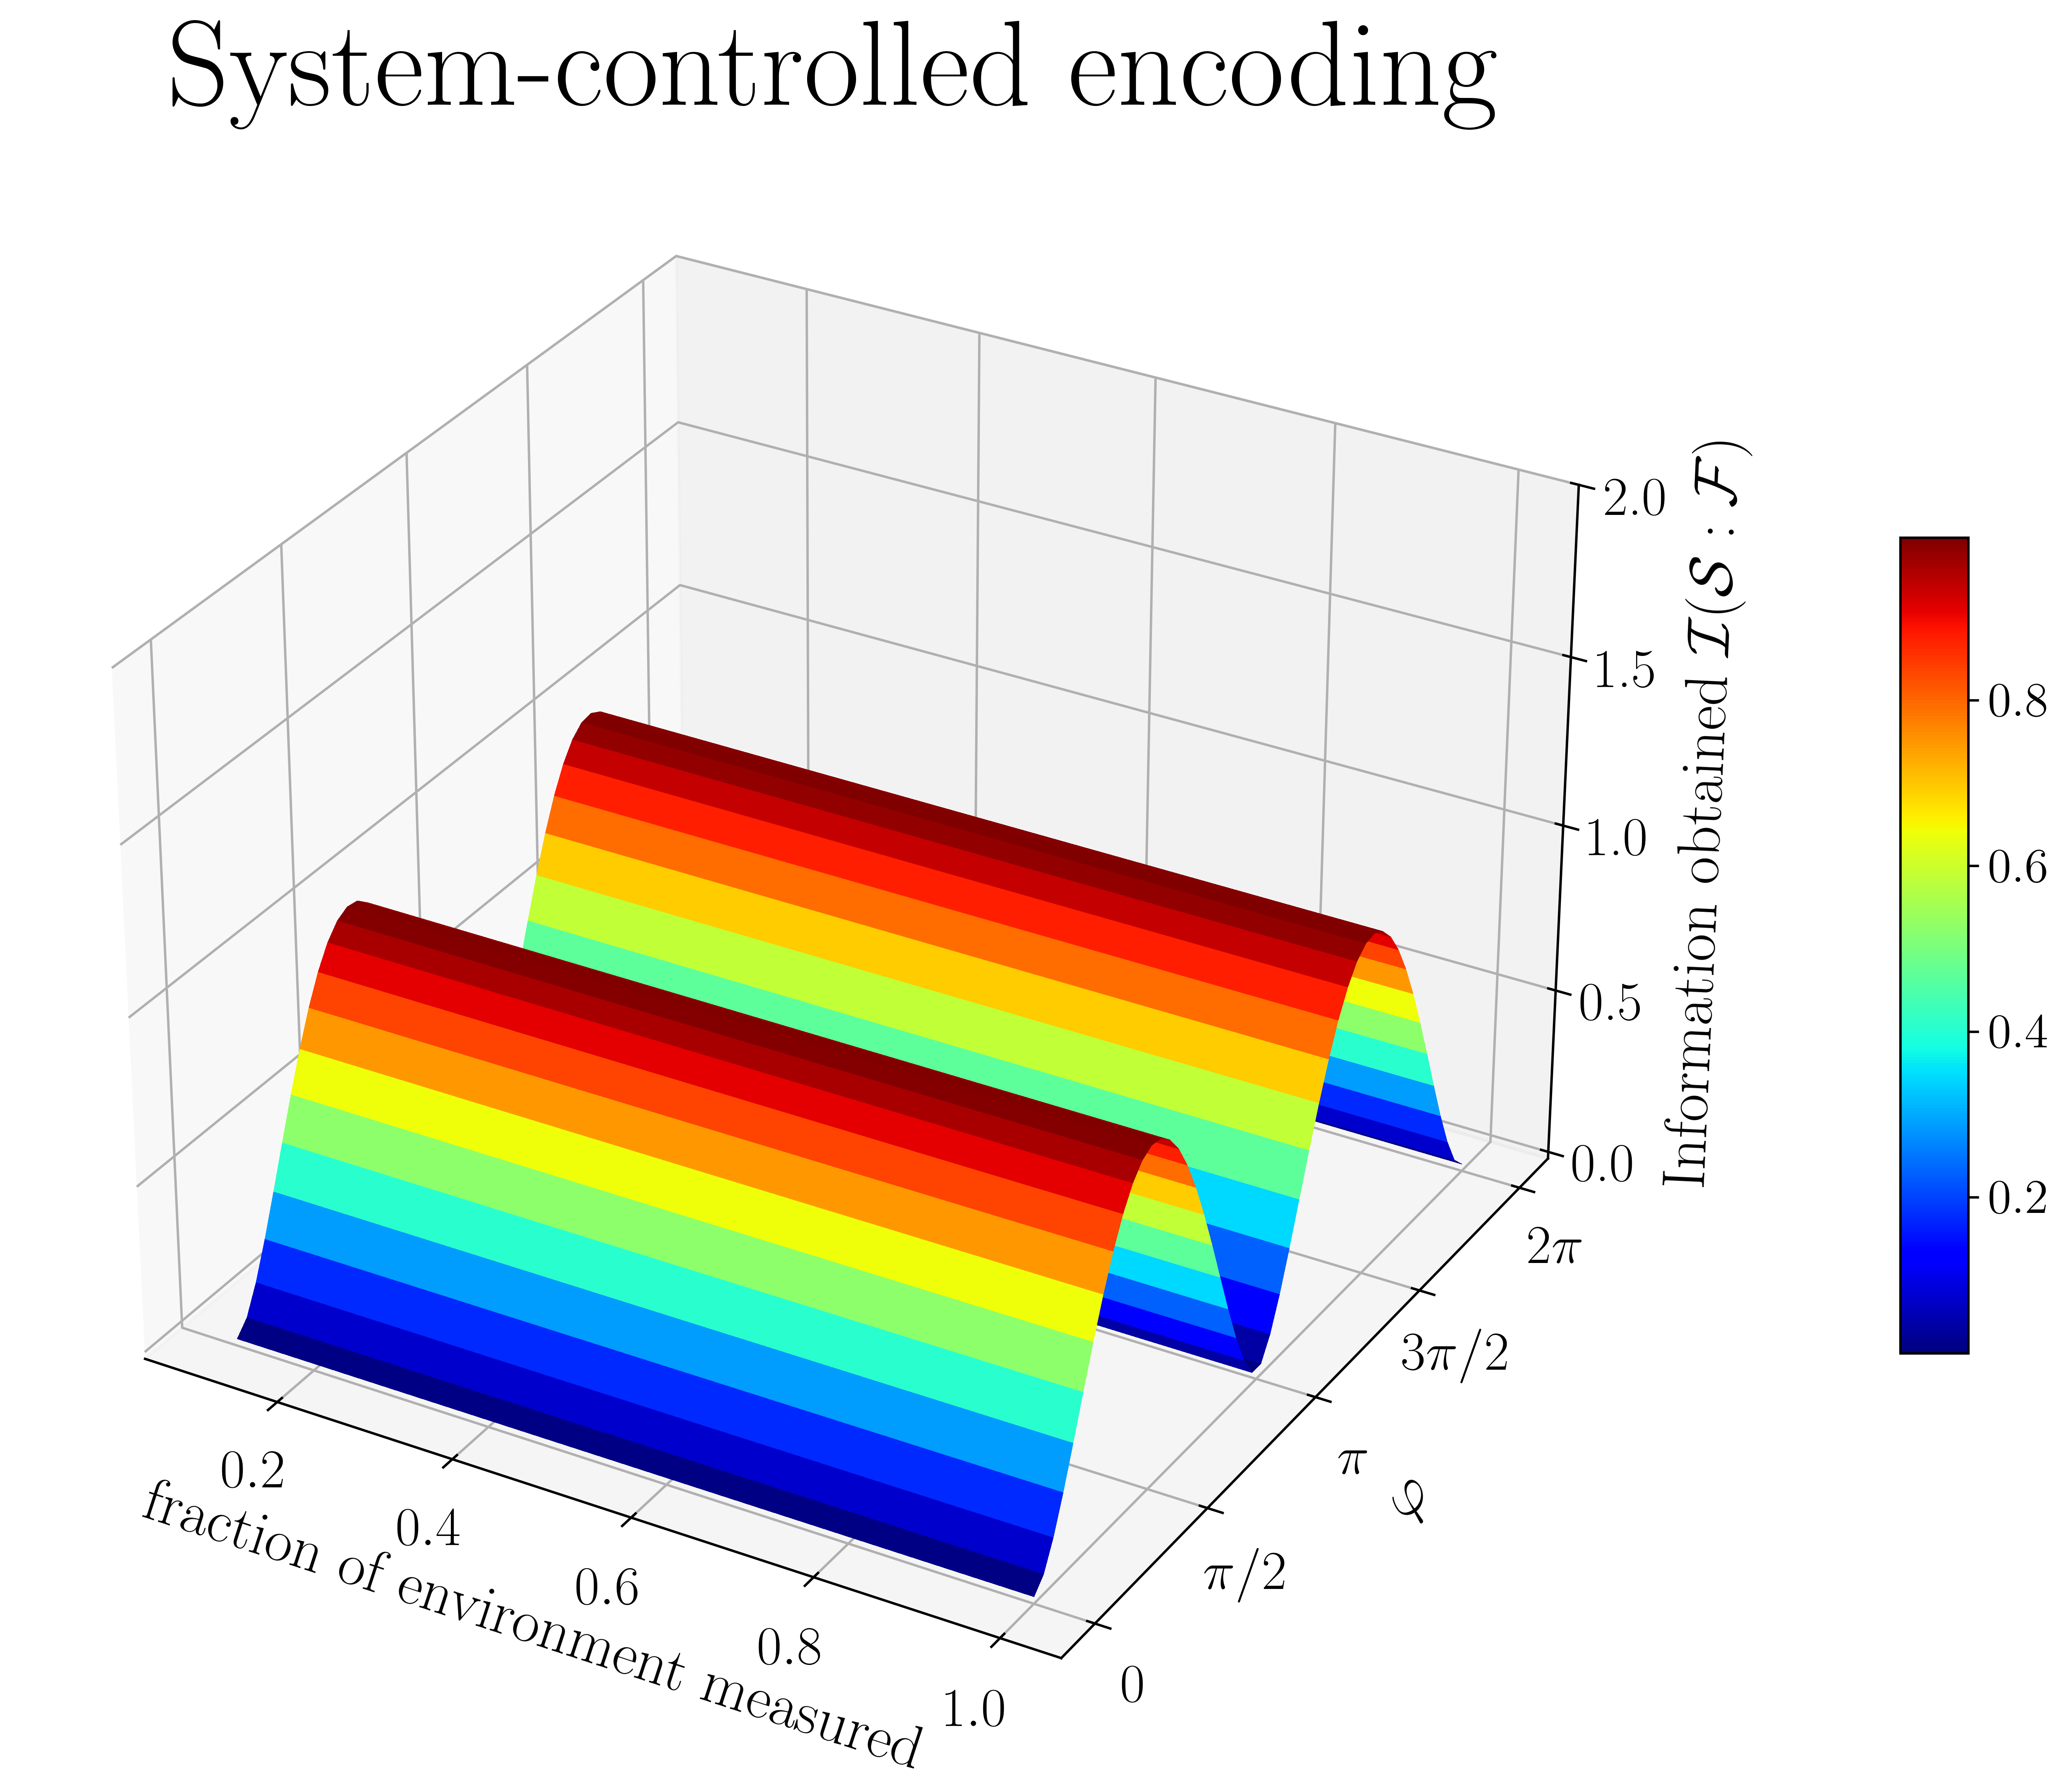

In [11]:
# PLOT Zurek model - QMI 3D Simulation
import pickle
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import os
import numpy as np
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl
import os
import pickle
import os
from IPython.display import display

os.environ["PATH"] += os.pathsep + "/Library/TeX/texbin"

mpl.rcParams['figure.dpi'] = 600
mpl.rcParams['text.usetex'] = True
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['font.serif'] = ['Computer Modern Roman']
mpl.rcParams['axes.unicode_minus'] = False
mpl.rcParams['savefig.transparent'] = False

# Load dữ liệu từ file pkl
with open("3D_QMI_Wigner.pkl", "rb") as f:
    loaded_data = pickle.load(f)

FS = loaded_data["FS"]
FS_norm = FS / 100.0
PhiSys = loaded_data["Phi_sys"]
QMI_matrix = loaded_data["QMI_matrix"]

# Vẽ lại 3D plot
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(
    FS_norm, PhiSys, QMI_matrix, 
    cmap='jet', 
    shade=False,        # Tắt bóng mờ chứa alpha ngầm
    antialiased=False,  # Tắt khử răng cưa chứa alpha ở mép
    linewidth=0
)


ax.set_xlabel('fraction of environment measured', fontsize=20, labelpad = 8)

ax.set_ylabel(r'$\varphi$', fontsize=20, labelpad=8)
ax.set_zlabel("Information obtained " + r'$\mathcal{I}(\mathcal{S}:\mathcal{F})$', 
              fontsize=20, labelpad=8)
# Chỉnh ticks cho trục z
ax.set_zticks([0.0, 0.5, 1.0, 1.5, 2.0])
ax.set_zticklabels(['0.0', '0.5', '1.0', '1.5', '2.0'])



ax.set_title('System-controlled encoding', fontsize=40, ha = 'center')


ax.set_yticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi])
ax.set_yticklabels(['0', r'$\pi/2$', r'$\pi$', r'$3\pi/2$', r'$2\pi$'])



ax.tick_params(axis='x', labelsize=18, width=2.5)
ax.tick_params(axis='y', labelsize=18, width=2.5)
ax.tick_params(axis='z', labelsize=18, width=2.5)

cbar = fig.colorbar(surf, shrink=0.5, aspect=12, pad=0.1)
cbar.ax.tick_params(labelsize=16)  # chỉnh size chữ số

fig.subplots_adjust(right=0.95, bottom=0.02, top=0.95, left=0.01)
for artist in fig.get_children():
    if hasattr(artist, 'set_alpha'):
        artist.set_alpha(1.0)


fig.savefig(r"Figure\3D_QMI_Wigner.png", dpi=600, bbox_inches='tight')
fig.savefig(r"Figure\3D_QMI_Wigner.eps", dpi=600, bbox_inches='tight')
plt.show()

